In [9]:
import benefits_defns

In [12]:
import importlib 
importlib.reload(benefits_defns)
from benefits_defns import *

In [2]:
import pandas as pd 
import numpy as np

In [3]:
path = '../../data/salary_sample_body_benefits_v3.parquet.gzip'

In [4]:
if path[-3:] == 'csv:':
    even_sample = pd.read_csv(path)
elif path[-3:] == 'zip':
    even_sample = pd.read_parquet(path)

In [5]:
even_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,EDU_ASSISTANCE,WLB,WELLBEING,HEALTH_WELLBEING,RECOGNITION,FAMILY,PARENTAL_LEAVE,CULTURE,EXPERIENCE_BUCKET,LOG_SALARY
0,b320dcdab94034000293d0c979dafd03543b828b,"San Jose, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,True,3-5 years,12.177416
1,39036fb07ef90297a94c281b153ee88c6d71c514,"Memphis, TN","Shelby, TN",Tennessee,54,"Professional, Scientific, and Technical Services",Master's degree,1,Full-time (> 32 hours),False,...,False,True,False,True,False,False,False,False,6-10 years,11.813585
2,a81d1896d80873ed098d16225633e2c085c38b5b,"Detroit, MI","Wayne, MI",Michigan,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,True,False,False,False,False,False,False,None Listed,11.169900
3,1031387a0b167843c4eba97e3d239c9aed4c7e19,"Grand Rapids, MI","Kent, MI",Michigan,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,False,3-5 years,11.670356
4,85e918411cbf9017505845fb6b9aced339507afb,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,False,1-2 years,11.407565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,a52ad16f54d407bdd566fff339ce0538584793f6,"Albany, OR","Linn, OR",Oregon,52,Finance and Insurance,No Education Listed,1,Full-time (> 32 hours),False,...,False,True,False,False,False,False,False,False,None Listed,10.635855
19996,47eead071d7aa1bb7f3e11e10476688deb22e324,"Lithia Springs, GA","Douglas, GA",Georgia,56,Administrative and Support and Waste Managemen...,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,False,3-5 years,10.551899
19997,20de39afaee660a555b7d99e8142f5f3906f0a29,"Lufkin, TX","Angelina, TX",Texas,44,Retail Trade,No Education Listed,3,Part-time / full-time,False,...,True,True,True,True,False,True,True,False,None Listed,10.097573
19998,561636d55907d615dcdb24a4ae8fd2777829e767,"Scottsdale, AZ","Maricopa, AZ",Arizona,72,Accommodation and Food Services,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,False,1-2 years,10.544288


In [17]:
pd.set_option('display.max_rows', 300)
even_sample.groupby([occupation, 'YEAR','AI ROLE']).size()

SOC_2021_2_NAME                                             YEAR  AI ROLE
Architecture and Engineering Occupations                    2019  False        11
                                                                  True         16
                                                            2020  False        13
                                                                  True         18
                                                            2021  False        31
                                                                  True         36
                                                            2022  False        38
                                                                  True         73
                                                            2023  False        42
                                                                  True        151
Arts, Design, Entertainment, Sports, and Media Occupations  2019  False        22
                        

In [19]:
occupations_select = ['Architecture and Engineering Occupations','Arts, Design, Entertainment, Sports, and Media Occupations','Business and Financial Operations Occupations','Community and Social Service Occupations','Computer and Mathematical Occupations',
'Educational Instruction and Library Occupations',
'Healthcare Practitioners and Technical Occupations',
'Legal Occupations',
'Life, Physical, and Social Science Occupations',
'Management Occupations', 
'Office and Administrative Support Occupations',
'Personal Care and Service Occupations', 'Production Occupations',
'Sales and Related Occupations',
'Transportation and Material Moving Occupations',
]

In [232]:
len(occupations_select)

15

In [20]:
even_sample_select = even_sample[even_sample[occupation].isin(occupations_select)]

# AI Role Demand Over Time

In [115]:
ai_role_raw = even_sample_select.groupby([occupation, 'YEAR'])['AI ROLE'].sum().reset_index()

In [118]:
role_total = even_sample_select.groupby([occupation, 'YEAR'])['AI ROLE'].count().reset_index()

In [119]:
role_total

,SOC_2021_2_NAME,YEAR,AI ROLE
0,Architecture and Engineering Occupations,2019,27
1,Architecture and Engineering Occupations,2020,31
2,Architecture and Engineering Occupations,2021,67
3,Architecture and Engineering Occupations,2022,111
4,Architecture and Engineering Occupations,2023,193
5,"Arts, Design, Entertainment, Sports, and Media...",2019,35
6,"Arts, Design, Entertainment, Sports, and Media...",2020,43
7,"Arts, Design, Entertainment, Sports, and Media...",2021,63
8,"Arts, Design, Entertainment, Sports, and Media...",2022,92
9,"Arts, Design, Entertainment, Sports, and Media...",2023,199


In [117]:
ai_role_raw

,SOC_2021_2_NAME,YEAR,AI ROLE
0,Architecture and Engineering Occupations,2019,16
1,Architecture and Engineering Occupations,2020,18
2,Architecture and Engineering Occupations,2021,36
3,Architecture and Engineering Occupations,2022,73
4,Architecture and Engineering Occupations,2023,151
5,"Arts, Design, Entertainment, Sports, and Media...",2019,13
6,"Arts, Design, Entertainment, Sports, and Media...",2020,14
7,"Arts, Design, Entertainment, Sports, and Media...",2021,23
8,"Arts, Design, Entertainment, Sports, and Media...",2022,41
9,"Arts, Design, Entertainment, Sports, and Media...",2023,135


In [26]:
ai_role_occupation = even_sample_select.groupby([occupation, 'YEAR'])['AI ROLE'].mean().reset_index()


In [28]:
ai_role_occupation.rename(columns={'AI ROLE':'AI ROLE %'}, inplace=True)

In [29]:
ai_role_occupation

,SOC_2021_2_NAME,YEAR,AI ROLE %
0,Architecture and Engineering Occupations,2019,0.592593
1,Architecture and Engineering Occupations,2020,0.580645
2,Architecture and Engineering Occupations,2021,0.537313
3,Architecture and Engineering Occupations,2022,0.657658
4,Architecture and Engineering Occupations,2023,0.782383
5,"Arts, Design, Entertainment, Sports, and Media...",2019,0.371429
6,"Arts, Design, Entertainment, Sports, and Media...",2020,0.325581
7,"Arts, Design, Entertainment, Sports, and Media...",2021,0.365079
8,"Arts, Design, Entertainment, Sports, and Media...",2022,0.445652
9,"Arts, Design, Entertainment, Sports, and Media...",2023,0.678392


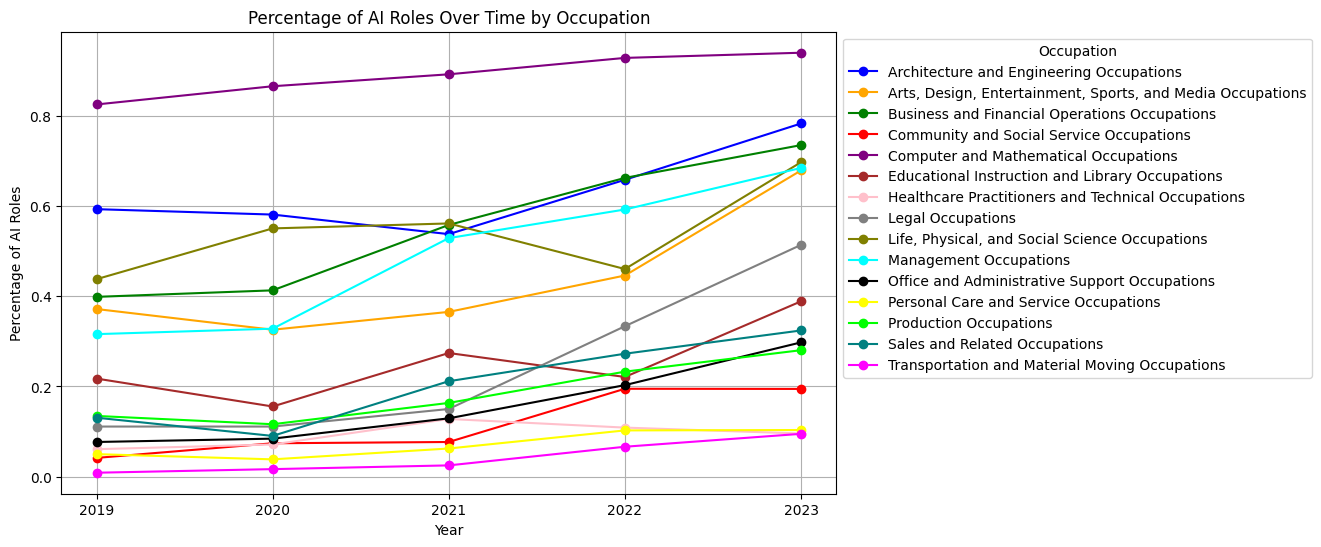

In [35]:
import matplotlib.pyplot as plt

# use different colors for each occupation
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'black', 'yellow', 'lime', 'teal', 'magenta']

# Create a pivot table where the index is 'YEAR' and columns are 'occupation'
pivot_data = ai_role_occupation.pivot(index='YEAR', columns=occupation, values='AI ROLE %')

# Plot each occupation's percentage of AI roles over time
pivot_data.plot(figsize=(10, 6), marker='o', color=colors)

# Adding titles and labels
plt.title('Percentage of AI Roles Over Time by Occupation')
# make x ticks only year integers
plt.xticks(np.arange(pivot_data.index.min(), pivot_data.index.max()+1, 1.0))
plt.xlabel('Year')
plt.ylabel('Percentage of AI Roles')
plt.legend(title='Occupation', bbox_to_anchor=(1, 1))
plt.grid(True)

# Show the plot
plt.show()


In [31]:
pivot_data

SOC_2021_2_NAME,Architecture and Engineering Occupations,"Arts, Design, Entertainment, Sports, and Media Occupations",Business and Financial Operations Occupations,Community and Social Service Occupations,Computer and Mathematical Occupations,Educational Instruction and Library Occupations,Healthcare Practitioners and Technical Occupations,Legal Occupations,"Life, Physical, and Social Science Occupations",Management Occupations,Office and Administrative Support Occupations,Personal Care and Service Occupations,Production Occupations,Sales and Related Occupations,Transportation and Material Moving Occupations
YEAR,,,,,,,,,,,,,,,
2019,0.592593,0.371429,0.398374,0.041667,0.824519,0.217391,0.060976,0.111111,0.437500,0.315789,0.076923,0.050000,0.134615,0.130719,0.008850
2020,0.580645,0.325581,0.412791,0.074074,0.864865,0.155556,0.071429,0.111111,0.550000,0.327869,0.084337,0.038462,0.116279,0.090361,0.016807
2021,0.537313,0.365079,0.557621,0.076923,0.891304,0.273973,0.127907,0.150000,0.560976,0.528517,0.129338,0.062500,0.163462,0.211538,0.025090
2022,0.657658,0.445652,0.661856,0.194805,0.927632,0.220930,0.108787,0.333333,0.460000,0.591876,0.202864,0.102564,0.232704,0.272425,0.066406
2023,0.782383,0.678392,0.734472,0.194444,0.939111,0.388489,0.095652,0.513514,0.696629,0.683908,0.297539,0.103448,0.280255,0.323944,0.095000


# % Roles Offering Benefit for AI/Non-AI Roles

In [208]:
occupation_benefits = even_sample_select.groupby([occupation, 'YEAR', 'AI ROLE'])[benefits3].mean().reset_index()

In [214]:
occupation_benefits_all = even_sample_select.groupby([occupation, 'YEAR'])[(benefits3 + ['LOG_SALARY'])].mean().reset_index()

In [218]:
occupation_benefits_all.rename(columns={'LOG_SALARY':'MEAN_LOG_SALARY'}, inplace=True)

In [216]:
pd.set_option('display.max_rows', 20)

In [219]:
occupation_benefits_all

,SOC_2021_2_NAME,YEAR,CAREER_DEV,EDU_ASSISTANCE,WLB,WELLBEING,HEALTH_WELLBEING,RECOGNITION,FAMILY,PARENTAL_LEAVE,CULTURE,MEAN_LOG_SALARY
0,Architecture and Engineering Occupations,2019,0.185185,0.000000,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.353368
1,Architecture and Engineering Occupations,2020,0.096774,0.000000,0.096774,0.000000,0.000000,0.000000,0.000000,0.000000,0.064516,11.376652
2,Architecture and Engineering Occupations,2021,0.194030,0.119403,0.328358,0.000000,0.014925,0.000000,0.029851,0.029851,0.014925,11.355574
3,Architecture and Engineering Occupations,2022,0.252252,0.180180,0.432432,0.009009,0.018018,0.027027,0.054054,0.054054,0.063063,11.542997
4,Architecture and Engineering Occupations,2023,0.238342,0.150259,0.461140,0.072539,0.082902,0.041451,0.129534,0.129534,0.181347,11.619209
...,...,...,...,...,...,...,...,...,...,...,...,...
70,Transportation and Material Moving Occupations,2019,0.185841,0.132743,0.274336,0.008850,0.017699,0.000000,0.008850,0.008850,0.008850,10.586468
71,Transportation and Material Moving Occupations,2020,0.071429,0.033613,0.361345,0.000000,0.121849,0.000000,0.012605,0.008403,0.004202,10.543131
72,Transportation and Material Moving Occupations,2021,0.179211,0.089606,0.440860,0.017921,0.078853,0.007168,0.035842,0.035842,0.021505,10.598748
73,Transportation and Material Moving Occupations,2022,0.210938,0.089844,0.496094,0.039062,0.054688,0.023438,0.054688,0.050781,0.066406,10.701070


In [209]:
occupation_benefits

,SOC_2021_2_NAME,YEAR,AI ROLE,CAREER_DEV,EDU_ASSISTANCE,WLB,WELLBEING,HEALTH_WELLBEING,RECOGNITION,FAMILY,PARENTAL_LEAVE,CULTURE
0,Architecture and Engineering Occupations,2019,False,0.181818,0.000000,0.090909,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Architecture and Engineering Occupations,2019,True,0.187500,0.000000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Architecture and Engineering Occupations,2020,False,0.000000,0.000000,0.076923,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,Architecture and Engineering Occupations,2020,True,0.166667,0.000000,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.111111
4,Architecture and Engineering Occupations,2021,False,0.129032,0.096774,0.322581,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
145,Transportation and Material Moving Occupations,2021,True,0.285714,0.285714,0.428571,0.000000,0.000000,0.000000,0.285714,0.285714,0.000000
146,Transportation and Material Moving Occupations,2022,False,0.217573,0.096234,0.514644,0.041841,0.058577,0.025105,0.050209,0.050209,0.066946
147,Transportation and Material Moving Occupations,2022,True,0.117647,0.000000,0.235294,0.000000,0.000000,0.000000,0.117647,0.058824,0.058824
148,Transportation and Material Moving Occupations,2023,False,0.232044,0.121547,0.546961,0.055249,0.099448,0.044199,0.049724,0.049724,0.066298


In [41]:
benefits_ai = occupation_benefits[occupation_benefits['AI ROLE'] == 1]
benefits_non_ai = occupation_benefits[occupation_benefits['AI ROLE'] == 0]

In [67]:
merged_df = pd.merge(benefits_ai, benefits_non_ai, on=['SOC_2021_2_NAME', 'YEAR'], suffixes=('_ai', '_non_ai'))


In [87]:
for benefit in benefits3:
    merged_df[f'{benefit}_premium'] = ((merged_df[f'{benefit}_ai'] - (merged_df[f'{benefit}_non_ai']
                                                                      ))*100).round(3)


In [88]:
for benefit in benefits3:
    merged_df[f'{benefit}_premium'] = merged_df[f'{benefit}_premium'].apply(lambda x: f'{x:.3f}' if pd.notnull(x) else x)

In [89]:
pd.set_option('display.max_columns', 300)

In [90]:
merged_df

,SOC_2021_2_NAME,YEAR,AI ROLE_ai,CAREER_DEV_ai,EDU_ASSISTANCE_ai,WLB_ai,WELLBEING_ai,HEALTH_WELLBEING_ai,RECOGNITION_ai,FAMILY_ai,PARENTAL_LEAVE_ai,CULTURE_ai,AI ROLE_non_ai,CAREER_DEV_non_ai,EDU_ASSISTANCE_non_ai,WLB_non_ai,WELLBEING_non_ai,HEALTH_WELLBEING_non_ai,RECOGNITION_non_ai,FAMILY_non_ai,PARENTAL_LEAVE_non_ai,CULTURE_non_ai,CAREER_DEV_premium,EDU_ASSISTANCE_premium,WLB_premium,WELLBEING_premium,HEALTH_WELLBEING_premium,RECOGNITION_premium,FAMILY_premium,PARENTAL_LEAVE_premium,CULTURE_premium
0,Architecture and Engineering Occupations,2019,True,0.187500,0.000000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,0.181818,0.000000,0.090909,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.568,0.000,3.409,0.000,0.000,0.000,0.000,0.000,0.000
1,Architecture and Engineering Occupations,2020,True,0.166667,0.000000,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.111111,False,0.000000,0.000000,0.076923,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.667,0.000,3.419,0.000,0.000,0.000,0.000,0.000,11.111
2,Architecture and Engineering Occupations,2021,True,0.250000,0.138889,0.333333,0.000000,0.027778,0.000000,0.055556,0.055556,0.027778,False,0.129032,0.096774,0.322581,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.097,4.211,1.075,0.000,2.778,0.000,5.556,5.556,2.778
3,Architecture and Engineering Occupations,2022,True,0.260274,0.178082,0.424658,0.000000,0.013699,0.041096,0.041096,0.041096,0.095890,False,0.236842,0.184211,0.447368,0.026316,0.026316,0.000000,0.078947,0.078947,0.000000,2.343,-0.613,-2.271,-2.632,-1.262,4.110,-3.785,-3.785,9.589
4,Architecture and Engineering Occupations,2023,True,0.258278,0.158940,0.470199,0.072848,0.092715,0.033113,0.145695,0.145695,0.185430,False,0.166667,0.119048,0.428571,0.071429,0.047619,0.071429,0.071429,0.071429,0.166667,9.161,3.989,4.163,0.142,4.510,-3.832,7.427,7.427,1.876
5,"Arts, Design, Entertainment, Sports, and Media...",2019,True,0.153846,0.000000,0.230769,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,0.136364,0.045455,0.363636,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.748,-4.545,-13.287,0.000,0.000,0.000,0.000,0.000,0.000
6,"Arts, Design, Entertainment, Sports, and Media...",2020,True,0.214286,0.000000,0.285714,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,0.034483,0.034483,0.206897,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.980,-3.448,7.882,0.000,0.000,0.000,0.000,0.000,0.000
7,"Arts, Design, Entertainment, Sports, and Media...",2021,True,0.086957,0.000000,0.086957,0.000000,0.000000,0.000000,0.000000,0.000000,0.086957,False,0.150000,0.075000,0.300000,0.000000,0.025000,0.025000,0.050000,0.050000,0.025000,-6.304,-7.500,-21.304,0.000,-2.500,-2.500,-5.000,-5.000,6.196
8,"Arts, Design, Entertainment, Sports, and Media...",2022,True,0.146341,0.048780,0.365854,0.048780,0.048780,0.000000,0.024390,0.024390,0.121951,False,0.156863,0.058824,0.313725,0.039216,0.058824,0.019608,0.039216,0.039216,0.019608,-1.052,-1.004,5.213,0.956,-1.004,-1.961,-1.483,-1.483,10.234
9,"Arts, Design, Entertainment, Sports, and Media...",2023,True,0.155556,0.088889,0.281481,0.022222,0.059259,0.022222,0.148148,0.140741,0.074074,False,0.218750,0.062500,0.328125,0.078125,0.093750,0.000000,0.046875,0.031250,0.046875,-6.319,2.639,-4.664,-5.590,-3.449,2.222,10.127,10.949,2.720


In [91]:
benefit_premium = merged_df[[occupation, 'YEAR'] + [f'{benefit}_premium' for benefit in benefits3]]

In [92]:
benefit_premium

,SOC_2021_2_NAME,YEAR,CAREER_DEV_premium,EDU_ASSISTANCE_premium,WLB_premium,WELLBEING_premium,HEALTH_WELLBEING_premium,RECOGNITION_premium,FAMILY_premium,PARENTAL_LEAVE_premium,CULTURE_premium
0,Architecture and Engineering Occupations,2019,0.568,0.000,3.409,0.000,0.000,0.000,0.000,0.000,0.000
1,Architecture and Engineering Occupations,2020,16.667,0.000,3.419,0.000,0.000,0.000,0.000,0.000,11.111
2,Architecture and Engineering Occupations,2021,12.097,4.211,1.075,0.000,2.778,0.000,5.556,5.556,2.778
3,Architecture and Engineering Occupations,2022,2.343,-0.613,-2.271,-2.632,-1.262,4.110,-3.785,-3.785,9.589
4,Architecture and Engineering Occupations,2023,9.161,3.989,4.163,0.142,4.510,-3.832,7.427,7.427,1.876
5,"Arts, Design, Entertainment, Sports, and Media...",2019,1.748,-4.545,-13.287,0.000,0.000,0.000,0.000,0.000,0.000
6,"Arts, Design, Entertainment, Sports, and Media...",2020,17.980,-3.448,7.882,0.000,0.000,0.000,0.000,0.000,0.000
7,"Arts, Design, Entertainment, Sports, and Media...",2021,-6.304,-7.500,-21.304,0.000,-2.500,-2.500,-5.000,-5.000,6.196
8,"Arts, Design, Entertainment, Sports, and Media...",2022,-1.052,-1.004,5.213,0.956,-1.004,-1.961,-1.483,-1.483,10.234
9,"Arts, Design, Entertainment, Sports, and Media...",2023,-6.319,2.639,-4.664,-5.590,-3.449,2.222,10.127,10.949,2.720


In [101]:
# set premium columns as float in benefit_premium
for benefit in benefits3:
    benefit_premium[f'{benefit}_premium'] = benefit_premium[f'{benefit}_premium'].astype(float)

/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_96965/3603880271.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  benefit_premium[f'{benefit}_premium'] = benefit_premium[f'{benefit}_premium'].astype(float)
/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_96965/3603880271.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  benefit_premium[f'{benefit}_premium'] = benefit_premium[f'{benefit}_premium'].astype(float)
/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_96965/3603880

In [104]:
# group benefits_premium by occupation, not year and get mean
# don't include year column in groupby
benefit_premium_grouped = benefit_premium.groupby(occupation).mean().reset_index()
benefit_premium_grouped.drop(columns='YEAR', inplace=True)

In [105]:
benefit_premium_grouped

,SOC_2021_2_NAME,CAREER_DEV_premium,EDU_ASSISTANCE_premium,WLB_premium,WELLBEING_premium,HEALTH_WELLBEING_premium,RECOGNITION_premium,FAMILY_premium,PARENTAL_LEAVE_premium,CULTURE_premium
0,Architecture and Engineering Occupations,8.1672,1.5174,1.9590,-0.4980,1.2052,0.0556,1.8396,1.8396,5.0708
1,"Arts, Design, Entertainment, Sports, and Media...",1.2106,-2.7716,-5.2320,-0.9268,-1.3906,-0.4478,0.7288,0.8932,3.8300
2,Business and Financial Operations Occupations,2.1498,1.6214,-3.2416,3.6384,4.4382,-0.1928,3.5378,3.6710,4.1596
3,Community and Social Service Occupations,-11.0864,-2.5662,2.8026,0.6940,-1.8506,-2.0452,-6.8132,-5.0386,20.8934
4,Computer and Mathematical Occupations,0.6504,1.1244,4.2636,3.0180,3.0726,0.3608,2.9322,3.0292,4.0814
5,Educational Instruction and Library Occupations,3.4980,-7.1380,-4.9574,-0.2476,3.9800,-1.0044,-14.7488,-0.6926,7.5074
6,Healthcare Practitioners and Technical Occupat...,0.4502,-6.5476,-9.5178,2.0000,2.0170,-0.6242,0.1126,0.6946,-0.0062
7,Legal Occupations,19.7228,19.6052,-0.8888,6.4108,2.6022,0.0000,26.2718,26.2718,4.8026
8,"Life, Physical, and Social Science Occupations",2.2110,2.9498,-6.0234,-0.3374,-1.0928,-2.2222,-0.1754,-0.4980,-3.2978
9,Management Occupations,0.0202,0.4670,-7.3162,3.7788,4.5856,2.0680,4.4736,3.9890,6.7208


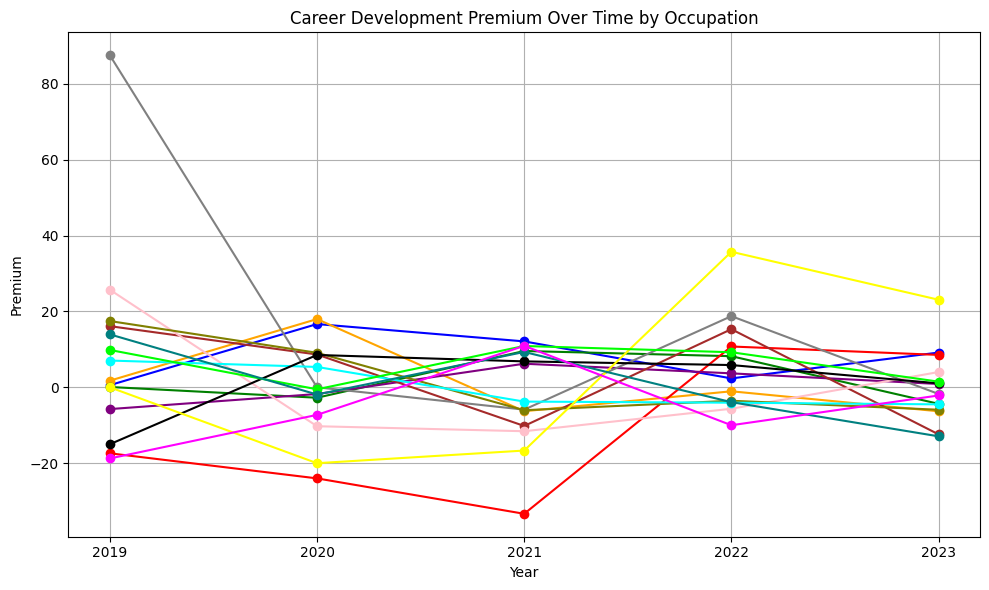

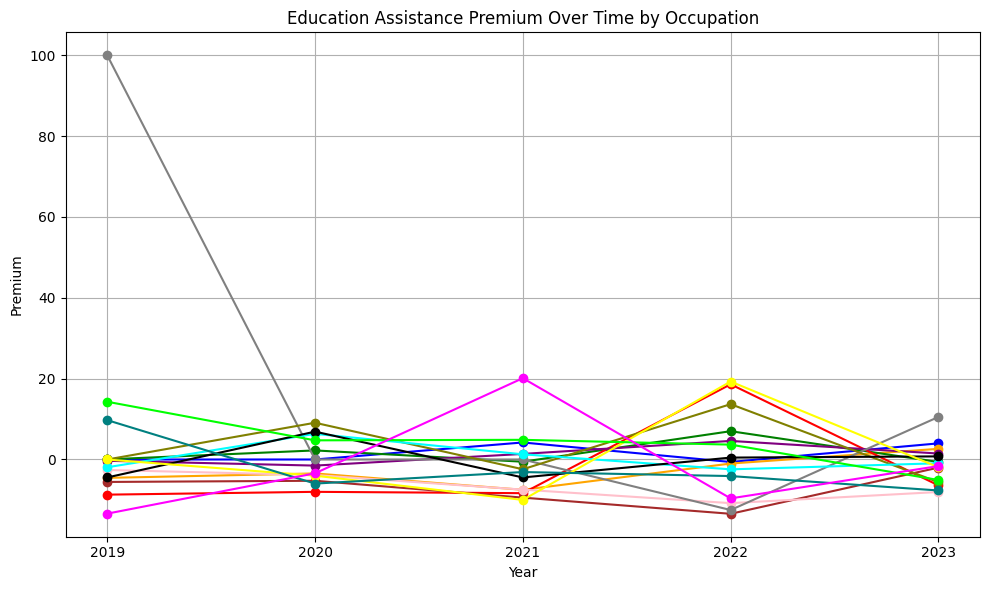

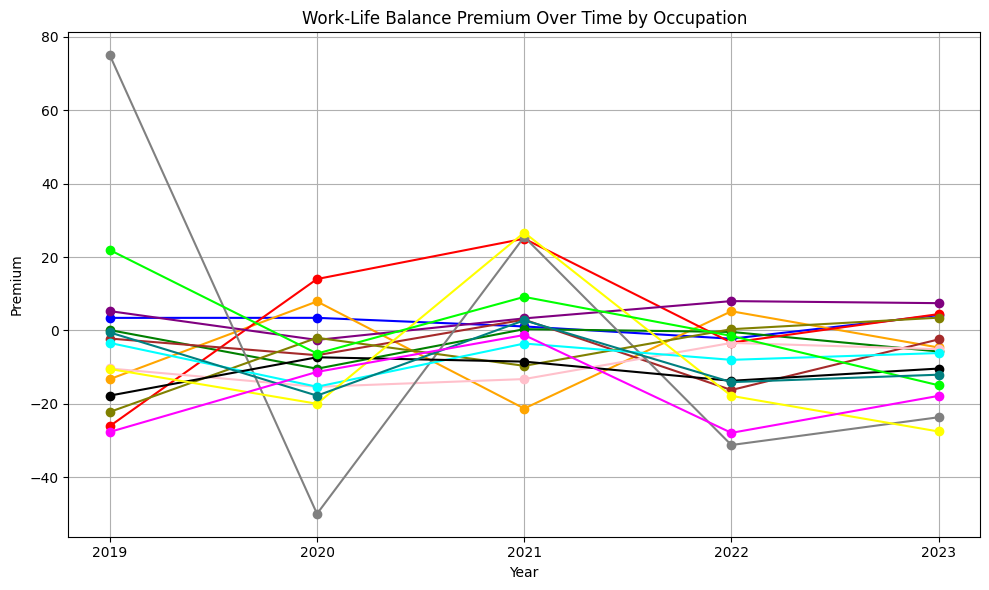

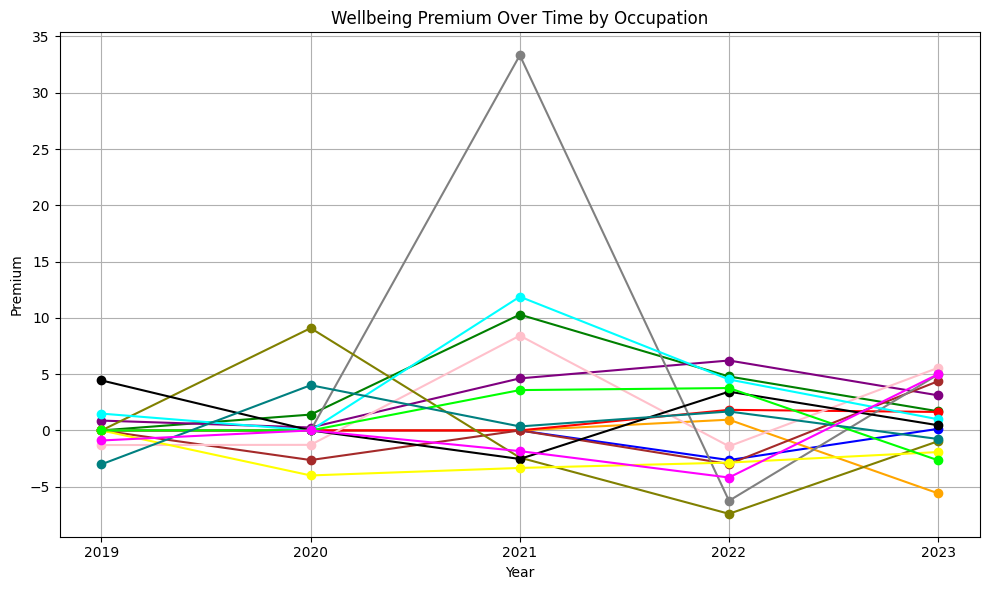

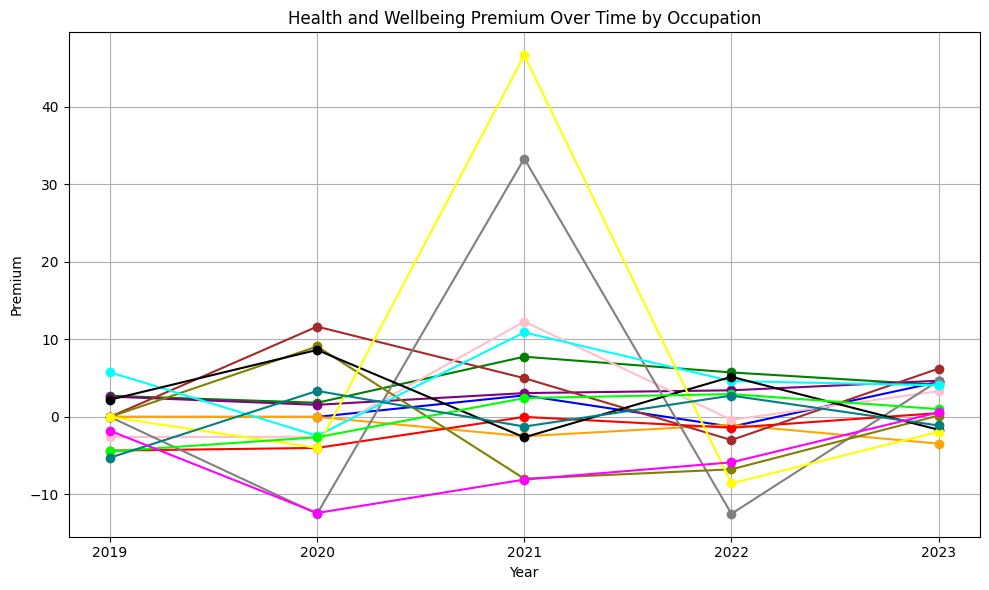

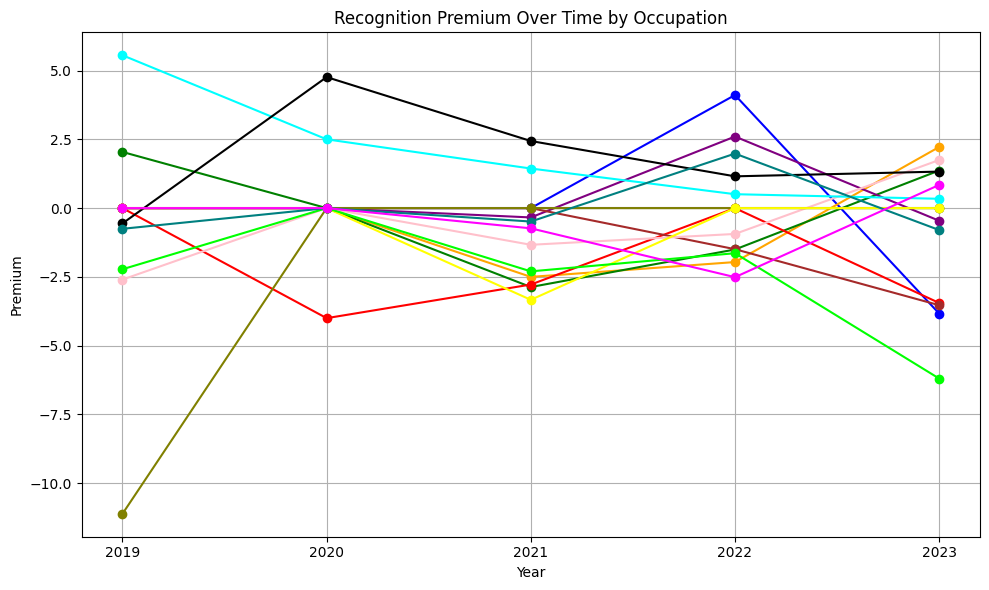

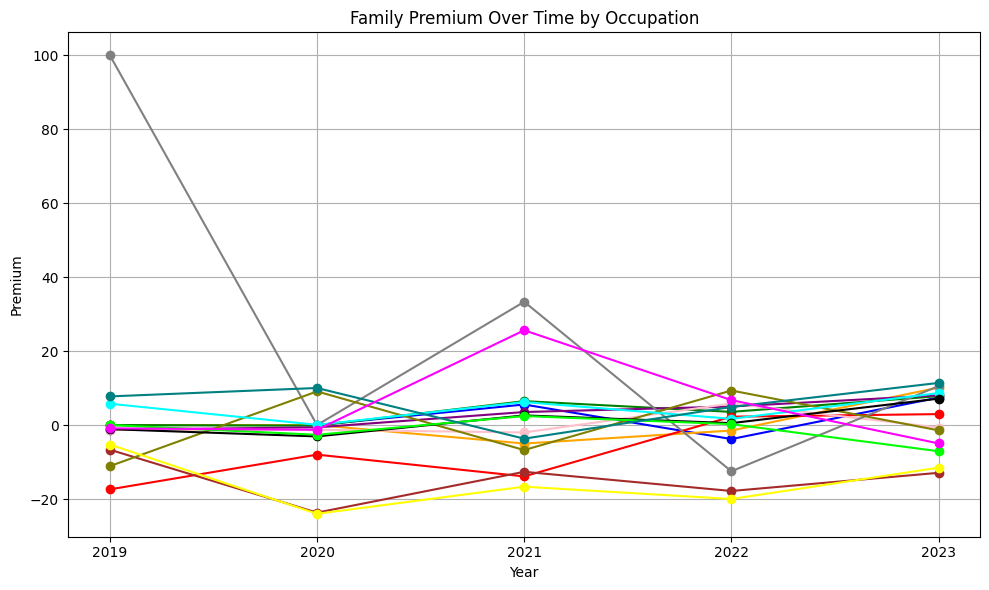

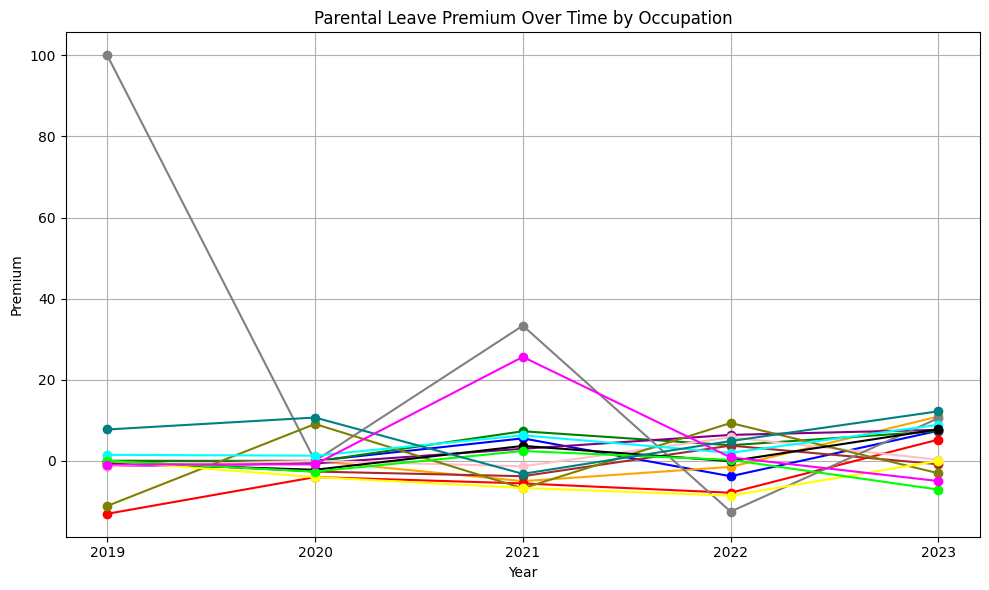

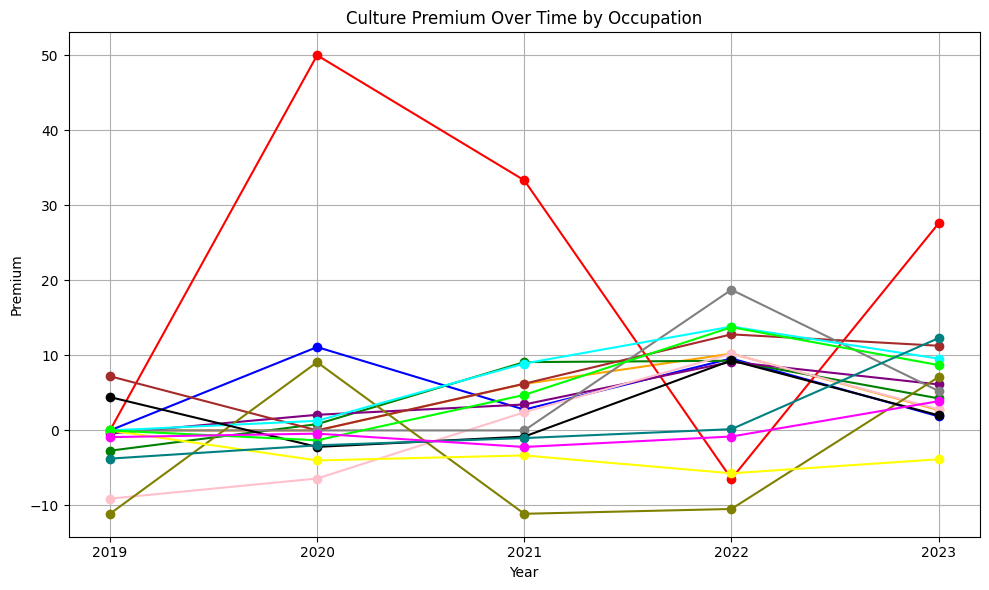

In [231]:
import matplotlib.pyplot as plt

# use different colors for each occupation
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'black', 'yellow', 'lime', 'teal', 'magenta']

for i, benefit in enumerate(benefits3):
    
    # Create a pivot table where the index is 'YEAR' and columns are 'occupation'
    pivot_data = benefit_premium.pivot(index='YEAR', columns=occupation, values=f'{benefit}_premium')

    # Plot each occupation's percentage of AI roles over time
    pivot_data.plot(figsize=(10, 6), marker='o', color=colors)
    benefit_label = benefits3_labels[i]
    # Adding titles and labels
    plt.title(f'{benefit_label} Premium Over Time by Occupation')
    # make x ticks only year integers
    plt.xticks(np.arange(pivot_data.index.min(), pivot_data.index.max()+1, 1.0))
    plt.xlabel('Year')
    plt.ylabel('Premium')
    # plt.legend(None)
    plt.grid(True)
    plt.tight_layout()
    plt.legend().remove()
    plt.savefig(f'../figures/{benefit}_premium_time.png')

    # Show the plot
    plt.show()


In [113]:
occ_year_df = benefit_premium.merge(ai_role_occupation, on=[occupation, 'YEAR'])

In [114]:
occ_year_df

,SOC_2021_2_NAME,YEAR,CAREER_DEV_premium,EDU_ASSISTANCE_premium,WLB_premium,WELLBEING_premium,HEALTH_WELLBEING_premium,RECOGNITION_premium,FAMILY_premium,PARENTAL_LEAVE_premium,CULTURE_premium,AI ROLE %
0,Architecture and Engineering Occupations,2019,0.568,0.000,3.409,0.000,0.000,0.000,0.000,0.000,0.000,0.592593
1,Architecture and Engineering Occupations,2020,16.667,0.000,3.419,0.000,0.000,0.000,0.000,0.000,11.111,0.580645
2,Architecture and Engineering Occupations,2021,12.097,4.211,1.075,0.000,2.778,0.000,5.556,5.556,2.778,0.537313
3,Architecture and Engineering Occupations,2022,2.343,-0.613,-2.271,-2.632,-1.262,4.110,-3.785,-3.785,9.589,0.657658
4,Architecture and Engineering Occupations,2023,9.161,3.989,4.163,0.142,4.510,-3.832,7.427,7.427,1.876,0.782383
5,"Arts, Design, Entertainment, Sports, and Media...",2019,1.748,-4.545,-13.287,0.000,0.000,0.000,0.000,0.000,0.000,0.371429
6,"Arts, Design, Entertainment, Sports, and Media...",2020,17.980,-3.448,7.882,0.000,0.000,0.000,0.000,0.000,0.000,0.325581
7,"Arts, Design, Entertainment, Sports, and Media...",2021,-6.304,-7.500,-21.304,0.000,-2.500,-2.500,-5.000,-5.000,6.196,0.365079
8,"Arts, Design, Entertainment, Sports, and Media...",2022,-1.052,-1.004,5.213,0.956,-1.004,-1.961,-1.483,-1.483,10.234,0.445652
9,"Arts, Design, Entertainment, Sports, and Media...",2023,-6.319,2.639,-4.664,-5.590,-3.449,2.222,10.127,10.949,2.720,0.678392


# Monetary Premium

In [129]:
occupation_salaries = occupation_benefits = even_sample_select.groupby([occupation, 'YEAR', 'AI ROLE'])[['LOG_SALARY', 'SALARY']].mean().reset_index()

In [130]:
occupation_salaries_ai = occupation_salaries[occupation_salaries['AI ROLE'] == 1]
occupation_salaries_non_ai = occupation_salaries[occupation_salaries['AI ROLE'] == 0]

In [131]:
occupation_salaries = pd.merge(occupation_salaries_ai, occupation_salaries_non_ai, on=[occupation, 'YEAR'], suffixes=('_ai', '_non_ai'))

In [132]:
occupation_salaries['SALARY_PREMIUM_LOG'] = ((occupation_salaries['LOG_SALARY_ai']/occupation_salaries['LOG_SALARY_non_ai'])*100)

In [133]:
occupation_salaries['SALARY_PREMIUM'] = ((occupation_salaries['SALARY_ai']/occupation_salaries['SALARY_non_ai'])*100)

In [134]:
occupation_salaries

,SOC_2021_2_NAME,YEAR,AI ROLE_ai,LOG_SALARY_ai,SALARY_ai,AI ROLE_non_ai,LOG_SALARY_non_ai,SALARY_non_ai,SALARY_PREMIUM_LOG,SALARY_PREMIUM
0,Architecture and Engineering Occupations,2019,True,11.387150,90796.187500,False,11.304232,87393.727273,100.733518,103.893255
1,Architecture and Engineering Occupations,2020,True,11.597093,116638.722222,False,11.071426,71873.923077,104.747961,162.282393
2,Architecture and Engineering Occupations,2021,True,11.561868,109740.583333,False,11.116007,75378.483871,104.010986,145.586085
3,Architecture and Engineering Occupations,2022,True,11.631612,119629.904110,False,11.372761,97191.000000,102.276066,123.087430
4,Architecture and Engineering Occupations,2023,True,11.673177,124427.569536,False,11.425182,97466.666667,102.170600,127.661665
5,"Arts, Design, Entertainment, Sports, and Media...",2019,True,11.261190,91136.461538,False,10.709071,49025.636364,105.155622,185.895520
6,"Arts, Design, Entertainment, Sports, and Media...",2020,True,11.113737,73104.142857,False,10.543366,42266.965517,105.409760,172.958106
7,"Arts, Design, Entertainment, Sports, and Media...",2021,True,11.057736,69753.521739,False,10.684153,47705.175000,103.496608,146.217935
8,"Arts, Design, Entertainment, Sports, and Media...",2022,True,11.063884,76376.609756,False,10.754831,52980.098039,102.873623,144.160945
9,"Arts, Design, Entertainment, Sports, and Media...",2023,True,11.156510,83305.251852,False,10.803178,55299.859375,103.270630,150.642791


Text(0.5, 1.0, 'Salary Premium Distribution')

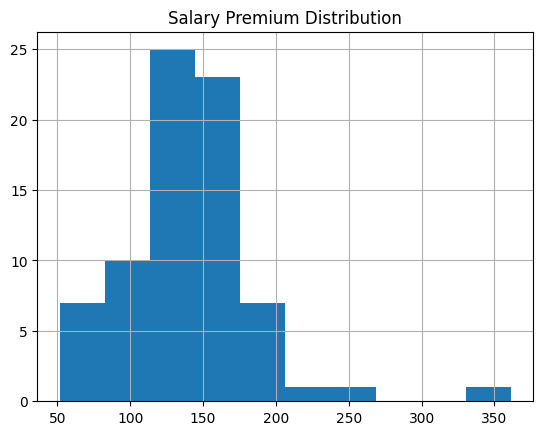

In [136]:
occupation_salaries['SALARY_PREMIUM'].hist()
plt.title('Salary Premium Distribution')

# Change in Demand

In [139]:
ai_role_occupation = ai_role_occupation.sort_values(by=[occupation, 'YEAR'])

In [141]:
ai_role_occupation['AI ROLE % CHANGE'] = ai_role_occupation.groupby(occupation)['AI ROLE %'].pct_change()

In [143]:
ai_role_occupation['AI ROLE % CHANGE'] = ai_role_occupation['AI ROLE % CHANGE']*100

In [144]:
ai_role_occupation

,SOC_2021_2_NAME,YEAR,AI ROLE %,AI ROLE % CHANGE
0,Architecture and Engineering Occupations,2019,0.592593,NaN
1,Architecture and Engineering Occupations,2020,0.580645,-2.016129
2,Architecture and Engineering Occupations,2021,0.537313,-7.462687
3,Architecture and Engineering Occupations,2022,0.657658,22.397397
4,Architecture and Engineering Occupations,2023,0.782383,18.965150
5,"Arts, Design, Entertainment, Sports, and Media...",2019,0.371429,NaN
6,"Arts, Design, Entertainment, Sports, and Media...",2020,0.325581,-12.343470
7,"Arts, Design, Entertainment, Sports, and Media...",2021,0.365079,12.131519
8,"Arts, Design, Entertainment, Sports, and Media...",2022,0.445652,22.069943
9,"Arts, Design, Entertainment, Sports, and Media...",2023,0.678392,52.224537


In [145]:
ai_role_occupation['PRIOR YEAR % CHANGE'] = ai_role_occupation.groupby(occupation)['AI ROLE % CHANGE'].shift(1)

In [146]:
ai_role_occupation

,SOC_2021_2_NAME,YEAR,AI ROLE %,AI ROLE % CHANGE,PRIOR YEAR % CHANGE
0,Architecture and Engineering Occupations,2019,0.592593,NaN,NaN
1,Architecture and Engineering Occupations,2020,0.580645,-2.016129,NaN
2,Architecture and Engineering Occupations,2021,0.537313,-7.462687,-2.016129
3,Architecture and Engineering Occupations,2022,0.657658,22.397397,-7.462687
4,Architecture and Engineering Occupations,2023,0.782383,18.965150,22.397397
5,"Arts, Design, Entertainment, Sports, and Media...",2019,0.371429,NaN,NaN
6,"Arts, Design, Entertainment, Sports, and Media...",2020,0.325581,-12.343470,NaN
7,"Arts, Design, Entertainment, Sports, and Media...",2021,0.365079,12.131519,-12.343470
8,"Arts, Design, Entertainment, Sports, and Media...",2022,0.445652,22.069943,12.131519
9,"Arts, Design, Entertainment, Sports, and Media...",2023,0.678392,52.224537,22.069943


In [147]:
occ_year_df = occ_year_df.merge(ai_role_occupation, on=[occupation, 'YEAR'])

In [150]:
occ_year_df

,SOC_2021_2_NAME,YEAR,CAREER_DEV_premium,EDU_ASSISTANCE_premium,WLB_premium,WELLBEING_premium,HEALTH_WELLBEING_premium,RECOGNITION_premium,FAMILY_premium,PARENTAL_LEAVE_premium,CULTURE_premium,AI ROLE %_x,AI ROLE %_y,AI ROLE % CHANGE,PRIOR YEAR % CHANGE
0,Architecture and Engineering Occupations,2019,0.568,0.000,3.409,0.000,0.000,0.000,0.000,0.000,0.000,0.592593,0.592593,NaN,NaN
1,Architecture and Engineering Occupations,2020,16.667,0.000,3.419,0.000,0.000,0.000,0.000,0.000,11.111,0.580645,0.580645,-2.016129,NaN
2,Architecture and Engineering Occupations,2021,12.097,4.211,1.075,0.000,2.778,0.000,5.556,5.556,2.778,0.537313,0.537313,-7.462687,-2.016129
3,Architecture and Engineering Occupations,2022,2.343,-0.613,-2.271,-2.632,-1.262,4.110,-3.785,-3.785,9.589,0.657658,0.657658,22.397397,-7.462687
4,Architecture and Engineering Occupations,2023,9.161,3.989,4.163,0.142,4.510,-3.832,7.427,7.427,1.876,0.782383,0.782383,18.965150,22.397397
5,"Arts, Design, Entertainment, Sports, and Media...",2019,1.748,-4.545,-13.287,0.000,0.000,0.000,0.000,0.000,0.000,0.371429,0.371429,NaN,NaN
6,"Arts, Design, Entertainment, Sports, and Media...",2020,17.980,-3.448,7.882,0.000,0.000,0.000,0.000,0.000,0.000,0.325581,0.325581,-12.343470,NaN
7,"Arts, Design, Entertainment, Sports, and Media...",2021,-6.304,-7.500,-21.304,0.000,-2.500,-2.500,-5.000,-5.000,6.196,0.365079,0.365079,12.131519,-12.343470
8,"Arts, Design, Entertainment, Sports, and Media...",2022,-1.052,-1.004,5.213,0.956,-1.004,-1.961,-1.483,-1.483,10.234,0.445652,0.445652,22.069943,12.131519
9,"Arts, Design, Entertainment, Sports, and Media...",2023,-6.319,2.639,-4.664,-5.590,-3.449,2.222,10.127,10.949,2.720,0.678392,0.678392,52.224537,22.069943


In [152]:
occ_year_df.drop(columns='AI ROLE %_y', inplace=True)

In [153]:
occ_year_df.rename(columns={'AI ROLE %_x':'AI ROLE %'}, inplace=True)

In [154]:
occ_year_df

,SOC_2021_2_NAME,YEAR,CAREER_DEV_premium,EDU_ASSISTANCE_premium,WLB_premium,WELLBEING_premium,HEALTH_WELLBEING_premium,RECOGNITION_premium,FAMILY_premium,PARENTAL_LEAVE_premium,CULTURE_premium,AI ROLE %,AI ROLE % CHANGE,PRIOR YEAR % CHANGE
0,Architecture and Engineering Occupations,2019,0.568,0.000,3.409,0.000,0.000,0.000,0.000,0.000,0.000,0.592593,NaN,NaN
1,Architecture and Engineering Occupations,2020,16.667,0.000,3.419,0.000,0.000,0.000,0.000,0.000,11.111,0.580645,-2.016129,NaN
2,Architecture and Engineering Occupations,2021,12.097,4.211,1.075,0.000,2.778,0.000,5.556,5.556,2.778,0.537313,-7.462687,-2.016129
3,Architecture and Engineering Occupations,2022,2.343,-0.613,-2.271,-2.632,-1.262,4.110,-3.785,-3.785,9.589,0.657658,22.397397,-7.462687
4,Architecture and Engineering Occupations,2023,9.161,3.989,4.163,0.142,4.510,-3.832,7.427,7.427,1.876,0.782383,18.965150,22.397397
5,"Arts, Design, Entertainment, Sports, and Media...",2019,1.748,-4.545,-13.287,0.000,0.000,0.000,0.000,0.000,0.000,0.371429,NaN,NaN
6,"Arts, Design, Entertainment, Sports, and Media...",2020,17.980,-3.448,7.882,0.000,0.000,0.000,0.000,0.000,0.000,0.325581,-12.343470,NaN
7,"Arts, Design, Entertainment, Sports, and Media...",2021,-6.304,-7.500,-21.304,0.000,-2.500,-2.500,-5.000,-5.000,6.196,0.365079,12.131519,-12.343470
8,"Arts, Design, Entertainment, Sports, and Media...",2022,-1.052,-1.004,5.213,0.956,-1.004,-1.961,-1.483,-1.483,10.234,0.445652,22.069943,12.131519
9,"Arts, Design, Entertainment, Sports, and Media...",2023,-6.319,2.639,-4.664,-5.590,-3.449,2.222,10.127,10.949,2.720,0.678392,52.224537,22.069943


In [155]:
occ_year_df = occ_year_df.merge(occupation_salaries, on=[occupation, 'YEAR'])

In [157]:
occ_year_df.drop(columns=['AI ROLE_ai', 'AI ROLE_non_ai'], inplace=True)

# Scatterplots

In [164]:
benefits3

['CAREER_DEV',
 'EDU_ASSISTANCE',
 'WLB',
 'WELLBEING',
 'HEALTH_WELLBEING',
 'RECOGNITION',
 'FAMILY',
 'PARENTAL_LEAVE',
 'CULTURE']

## Vs AI Demand

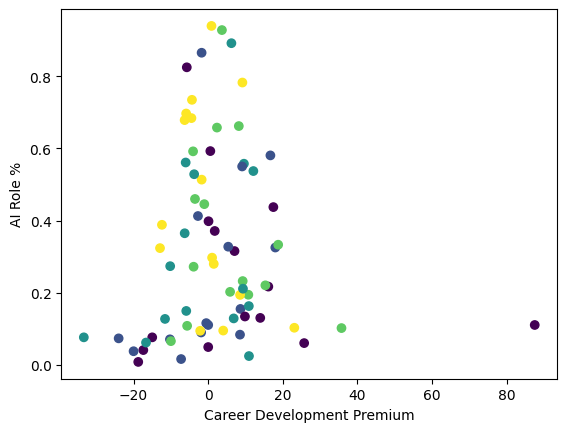

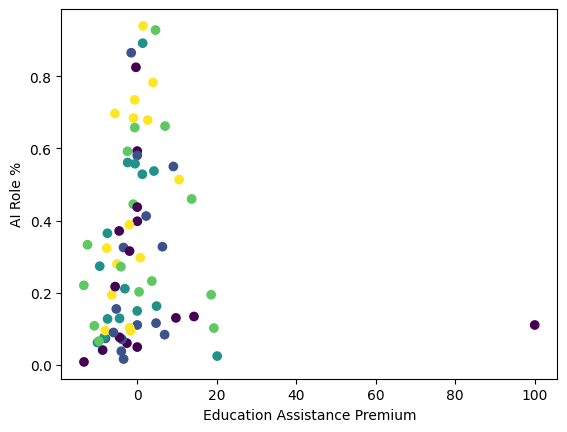

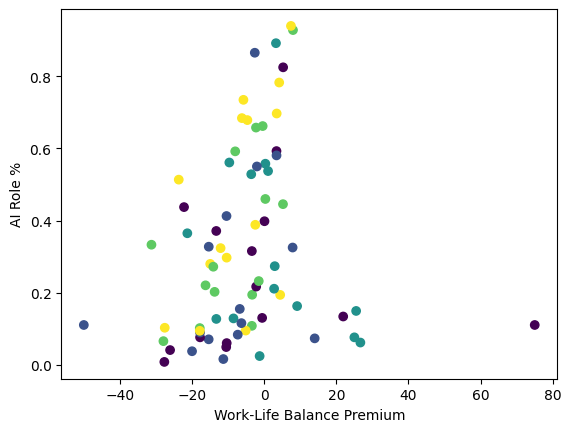

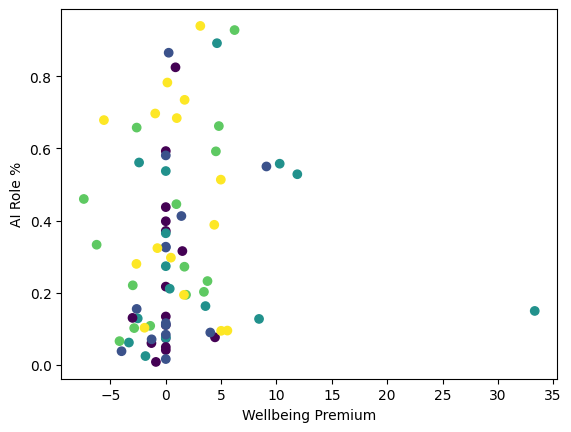

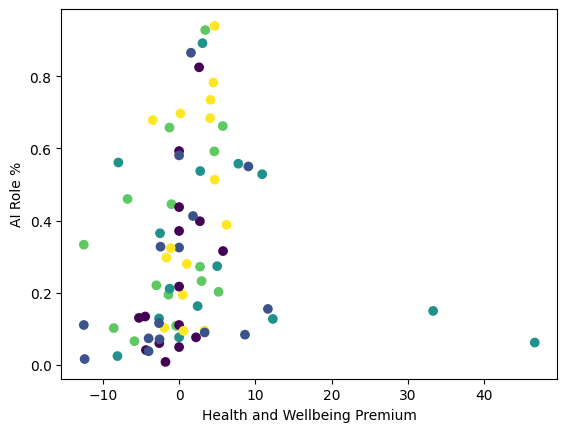

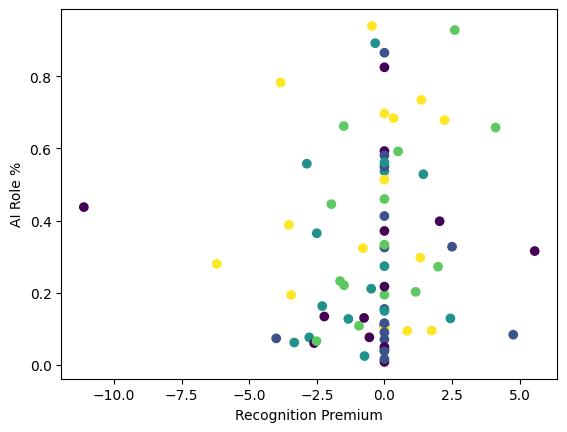

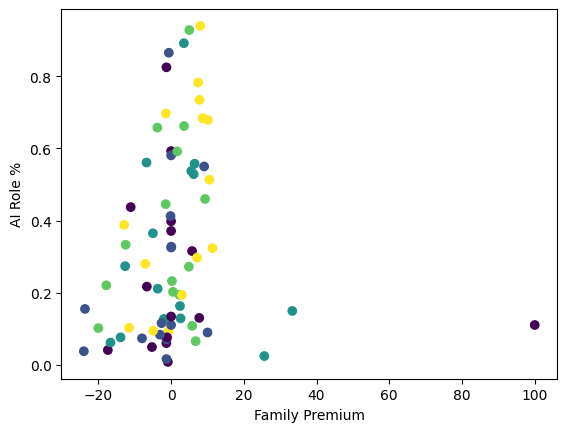

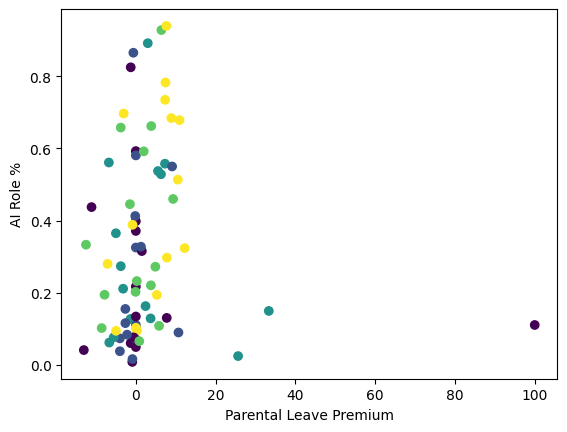

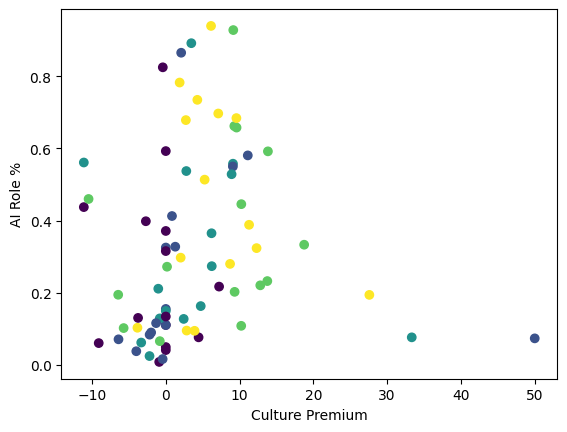

In [167]:
# scatterplot of CAREER PREMIUM vs AI ROLE %
import seaborn as sns
for i, benefit in enumerate(benefits3):
    plt.scatter(occ_year_df[f'{benefit}_premium'], occ_year_df['AI ROLE %'], c=occ_year_df[year])
    plt.xlabel(f'{benefits3_labels[i]} Premium')
    plt.ylabel('AI Role %')
    plt.show()


## Color by Occupation

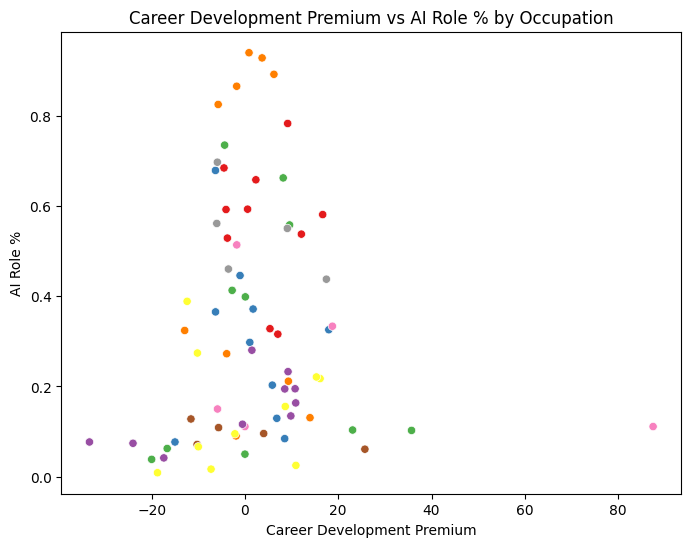

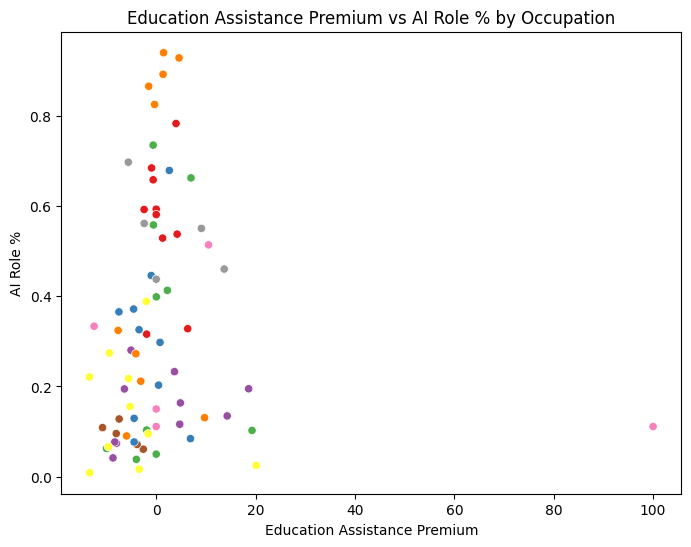

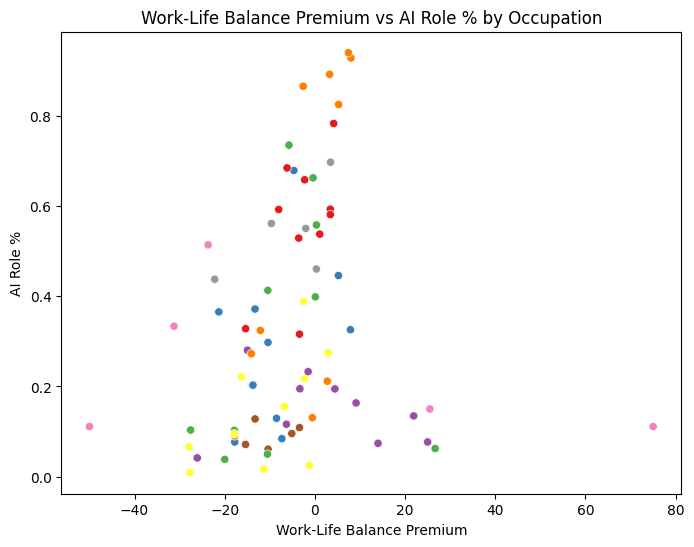

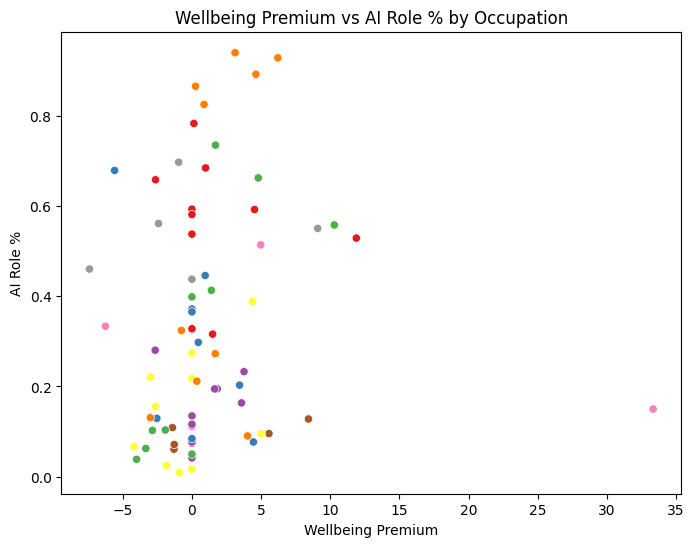

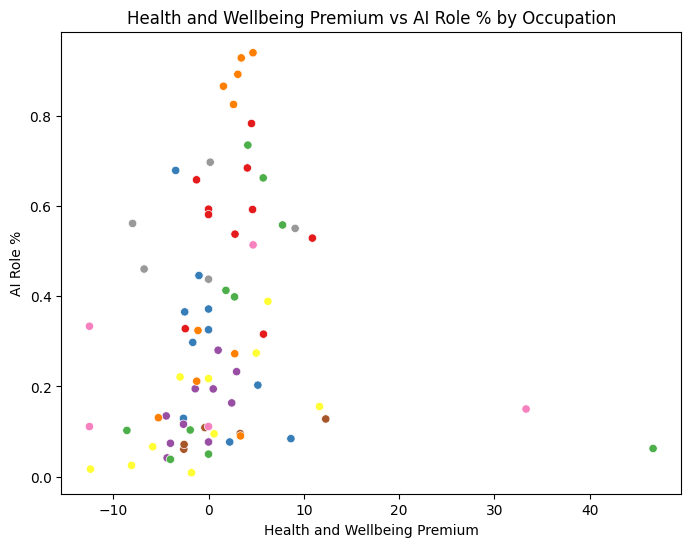

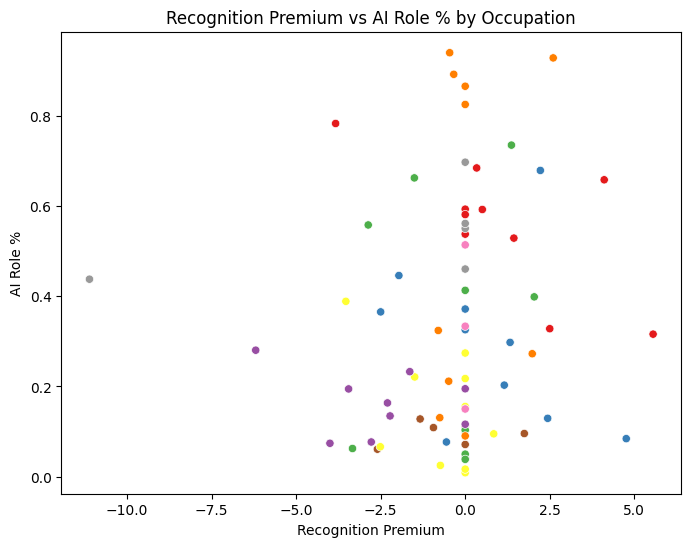

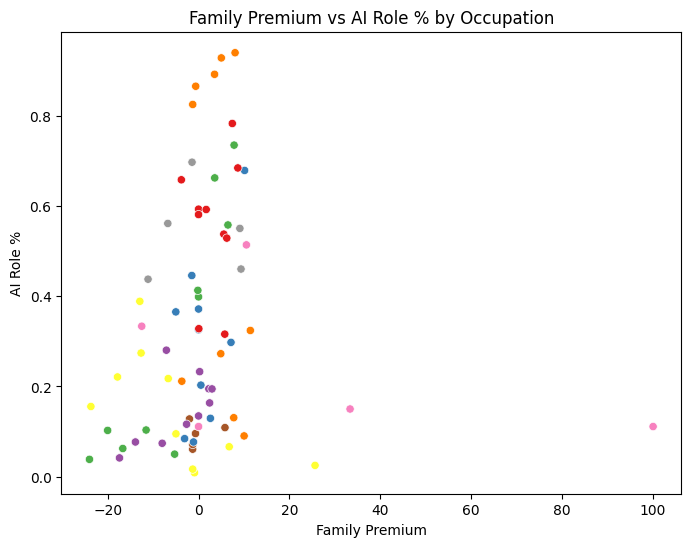

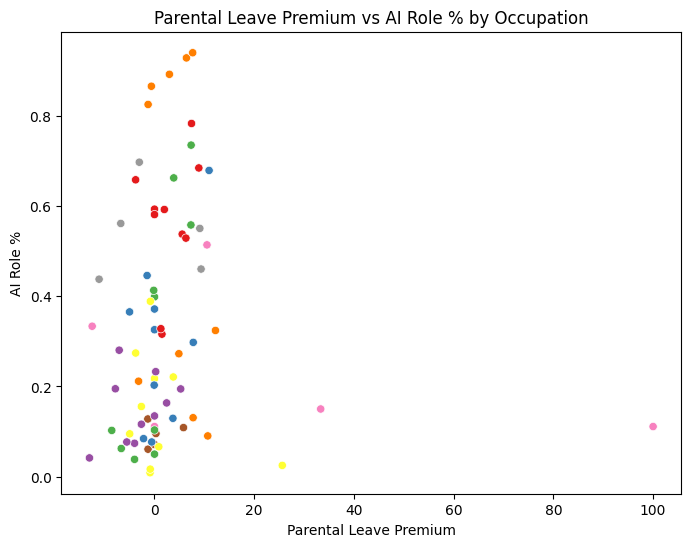

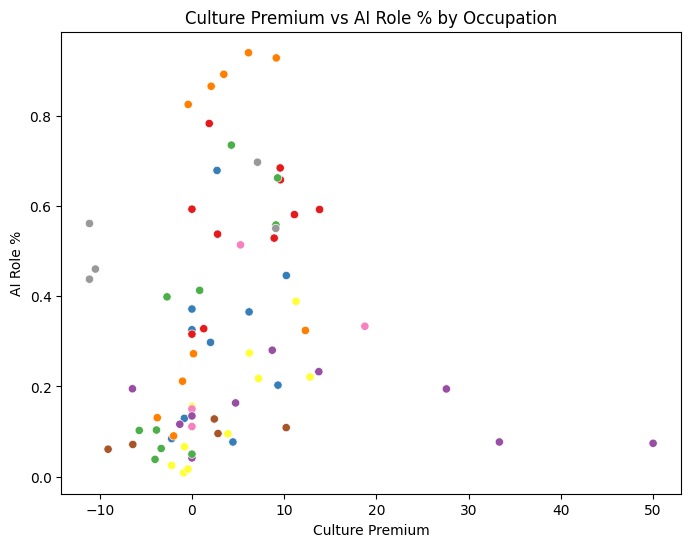

In [179]:
for i, benefit in enumerate(benefits3):
    plt.figure(figsize=(8, 6))
    # Remove outliers for each benefit's premium and 'AI ROLE %'
    # filtered_df = remove_outliers(occ_year_df, f'{benefit}_premium')
    # filtered_df = remove_outliers(filtered_df, 'AI ROLE %')
    # Create a scatterplot with color mapped to 'SOC_2021_2_NAME' (occupation)
    sns.scatterplot(
        data=occ_year_df, 
        x=f'{benefit}_premium', 
        y='AI ROLE %', 
        hue='SOC_2021_2_NAME',  # Color by occupation
        palette='Set1',         # Optional: Choose a color palette
        legend=False
    )
    
    # Set axis labels and title
    plt.xlabel(f'{benefits3_labels[i]} Premium')
    plt.ylabel('AI Role %')
    plt.title(f'{benefits3_labels[i]} Premium vs AI Role % by Occupation')
    plt.savefig(f'../figures/scatter_premium_vs_ai_demand_{benefit}.png')
    
    # Show the plot
    plt.show()

### Without Outliers

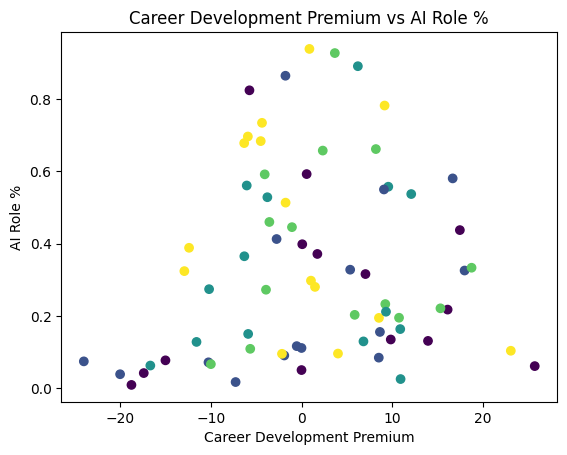

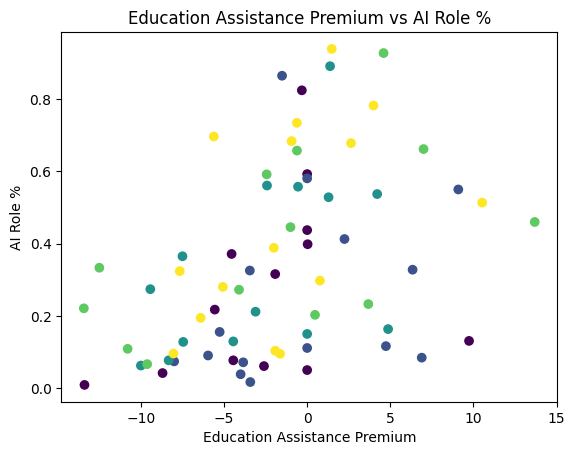

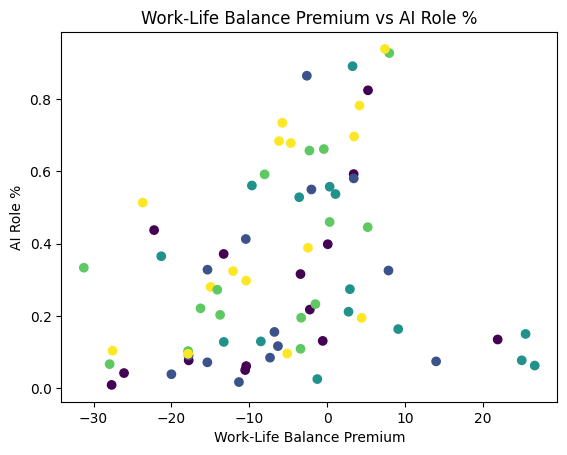

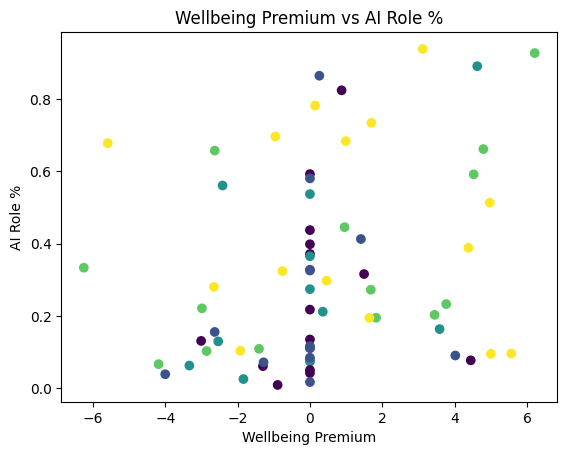

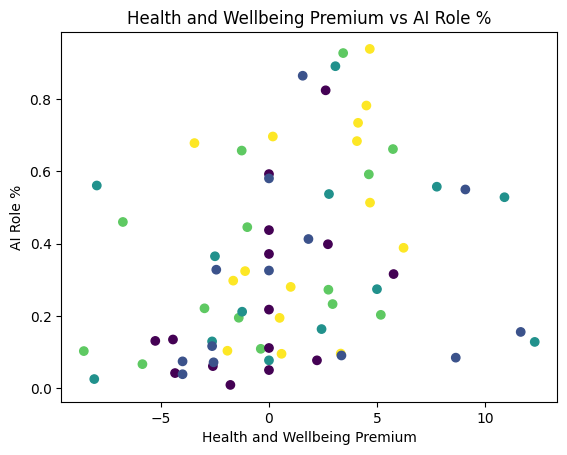

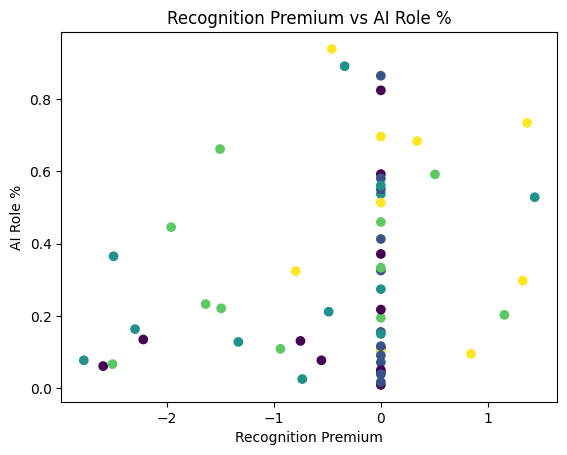

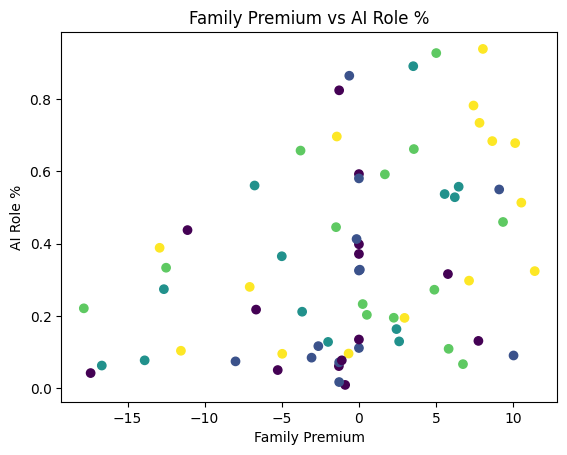

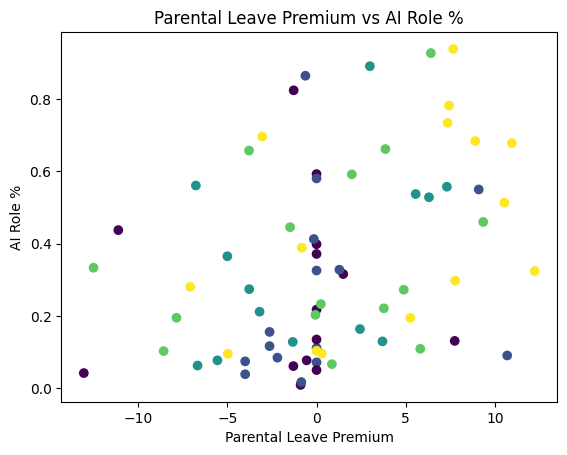

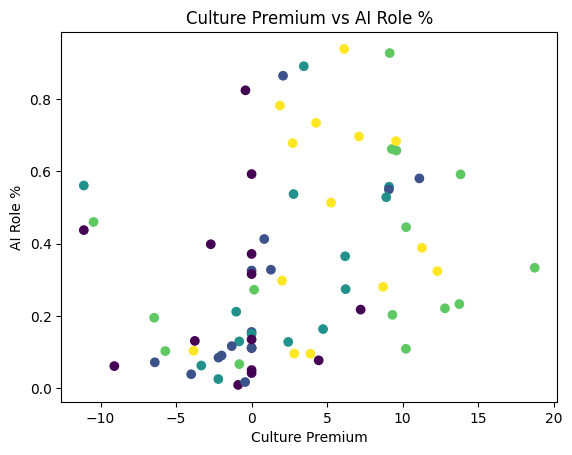

In [165]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    # Define outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Iterate through each benefit and plot the scatterplot without outliers
for i, benefit in enumerate(benefits3):
    # Remove outliers for each benefit's premium and 'AI ROLE %'
    filtered_df = remove_outliers(occ_year_df, f'{benefit}_premium')
    filtered_df = remove_outliers(filtered_df, 'AI ROLE %')
    
    # Plot the scatterplot after removing outliers
    plt.scatter(filtered_df[f'{benefit}_premium'], filtered_df['AI ROLE %'], c=filtered_df[year])
    plt.xlabel(f'{benefits3_labels[i]} Premium')
    plt.ylabel('AI Role %')
    plt.title(f'{benefits3_labels[i]} Premium vs AI Role %')
    plt.show()

## Change in Demand

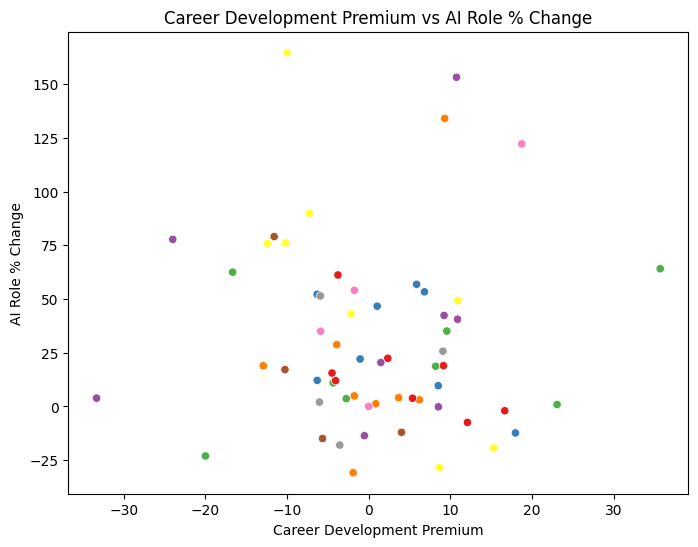

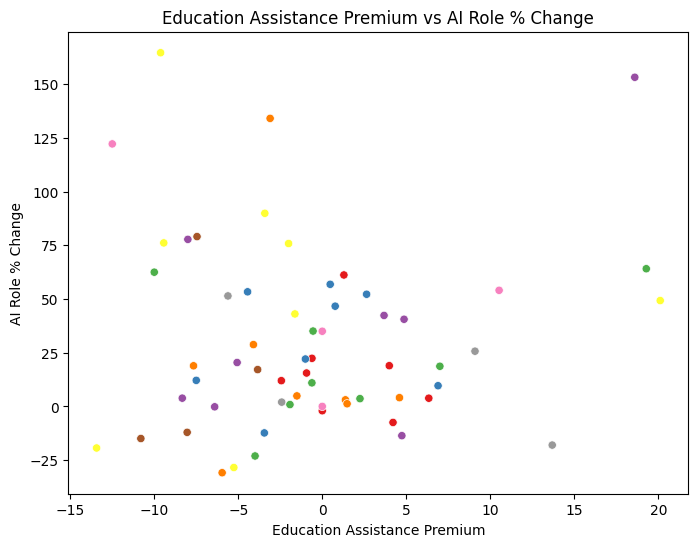

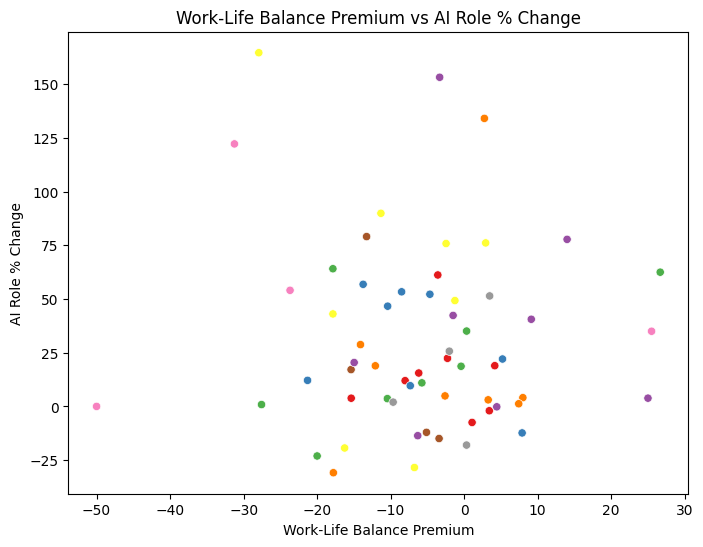

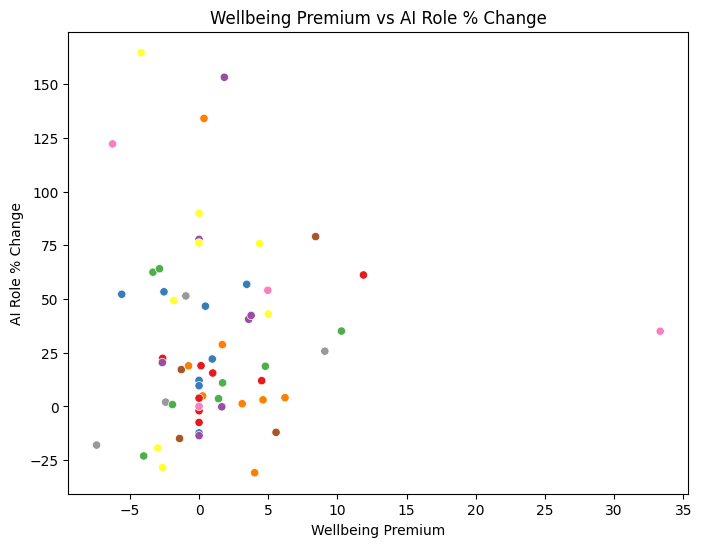

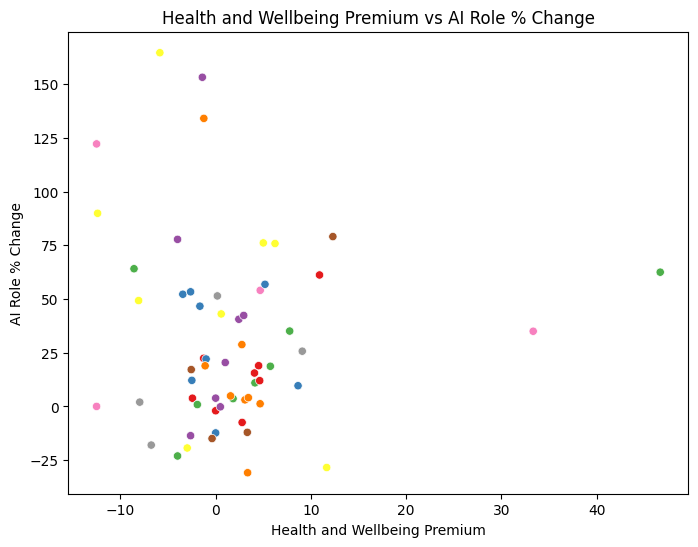

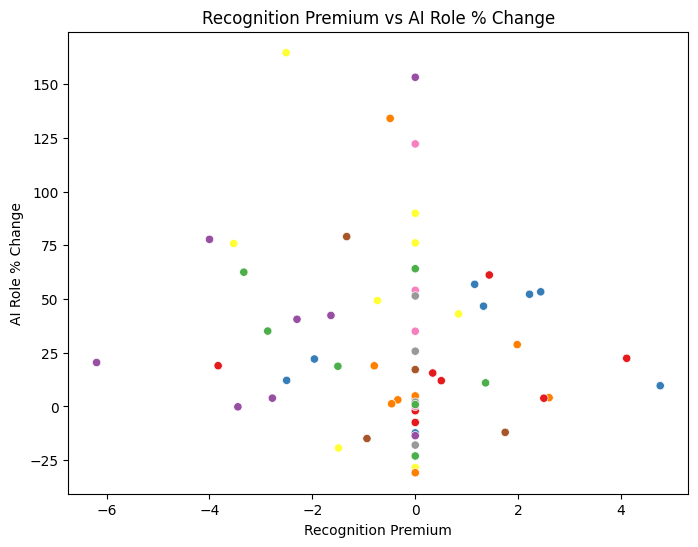

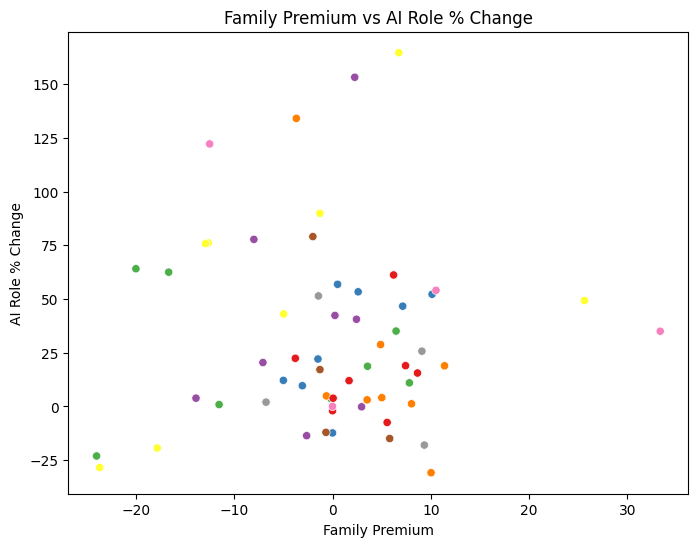

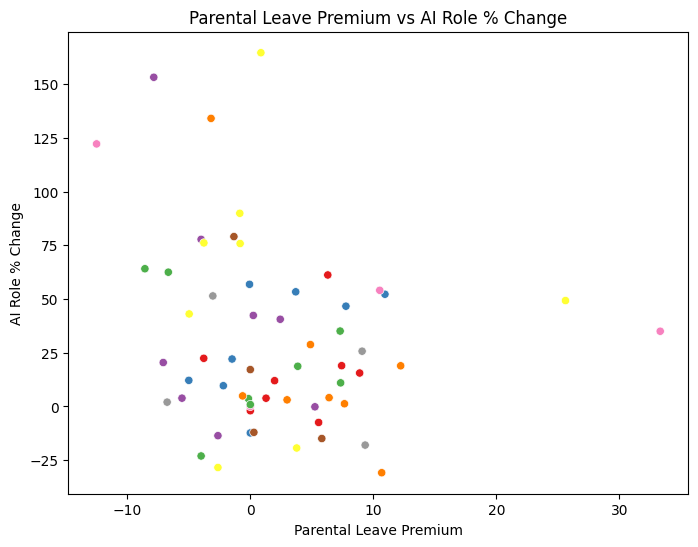

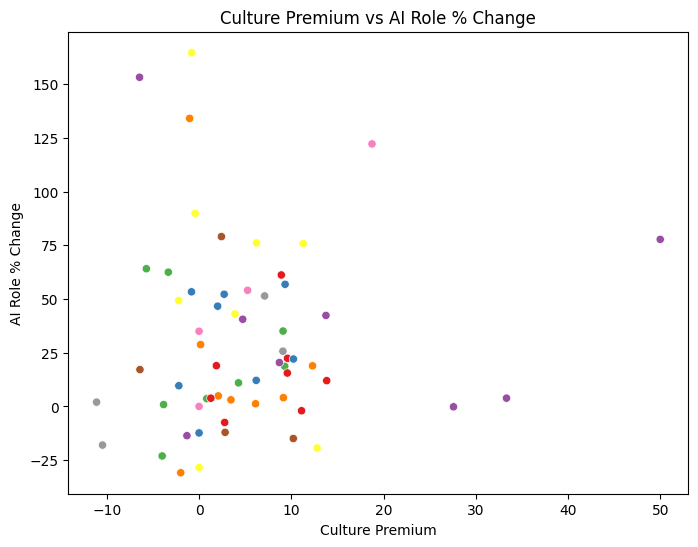

In [180]:
for i, benefit in enumerate(benefits3):
    plt.figure(figsize=(8, 6))
    
    # Create a scatterplot with color mapped to 'SOC_2021_2_NAME' (occupation)
    sns.scatterplot(
        data=occ_year_df, 
        x=f'{benefit}_premium', 
        y='AI ROLE % CHANGE', 
        hue='SOC_2021_2_NAME',  # Color by occupation
        palette='Set1',         # Optional: Choose a color palette
        legend=False
    )
    
    # Set axis labels and title
    plt.xlabel(f'{benefits3_labels[i]} Premium')
    plt.ylabel('AI Role % Change')
    plt.title(f'{benefits3_labels[i]} Premium vs AI Role % Change')
    plt.savefig(f'../figures/scatter_premium_vs_ai_demand_change_{benefit}.png')
    
    # Show the plot
    plt.show()

## AI Role Prior Year Change

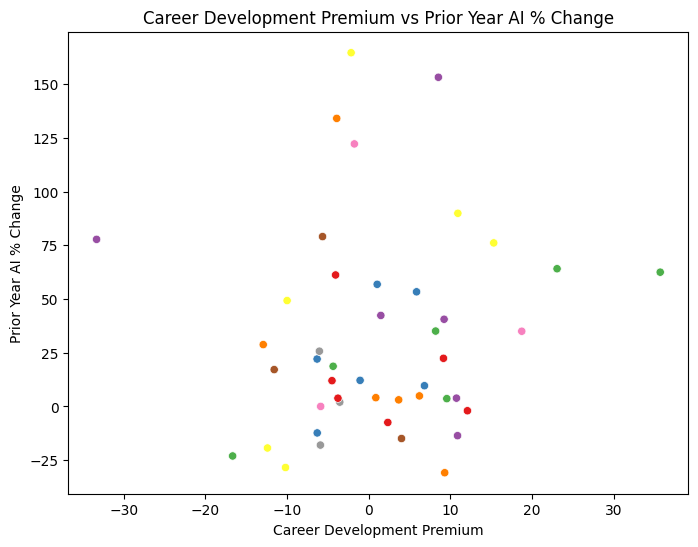

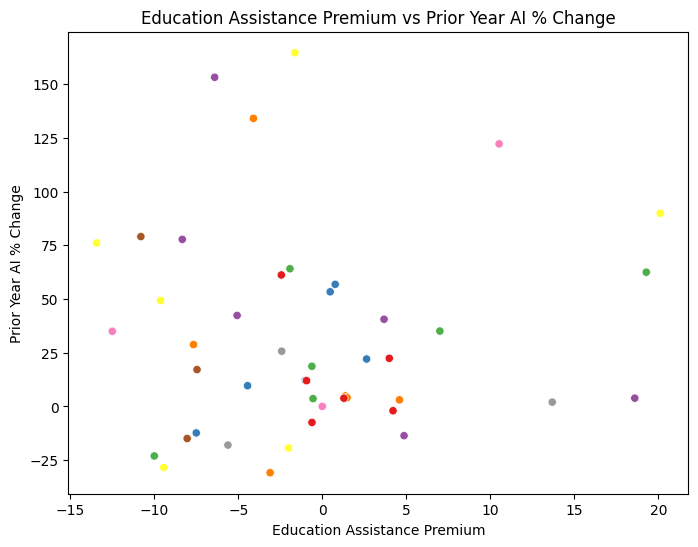

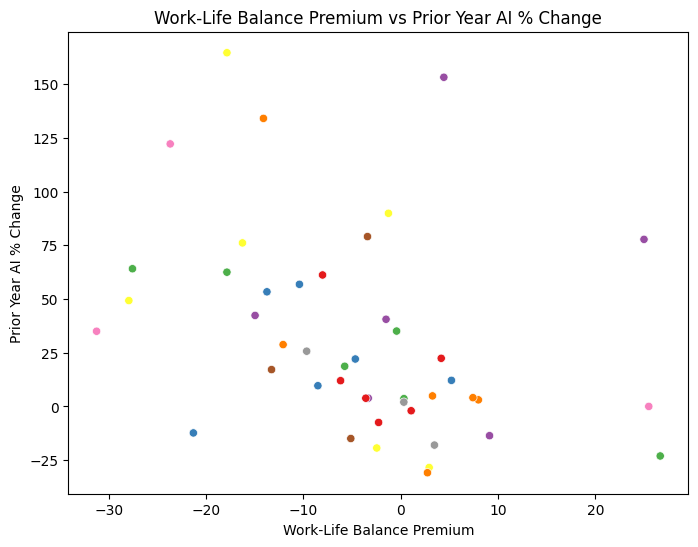

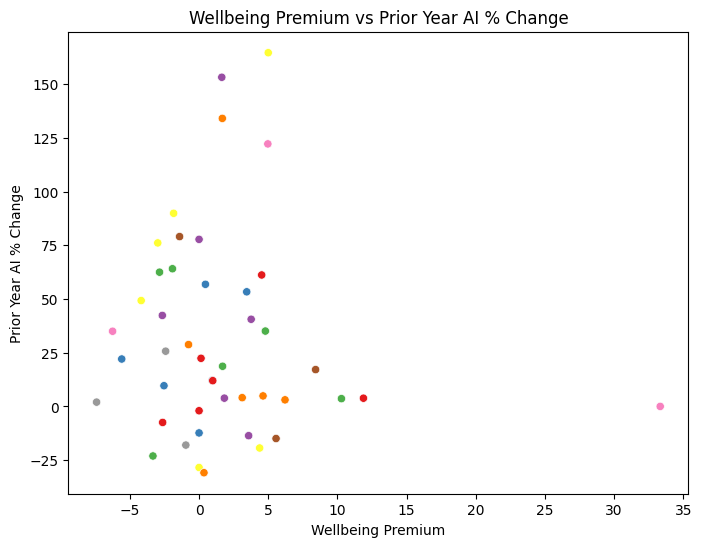

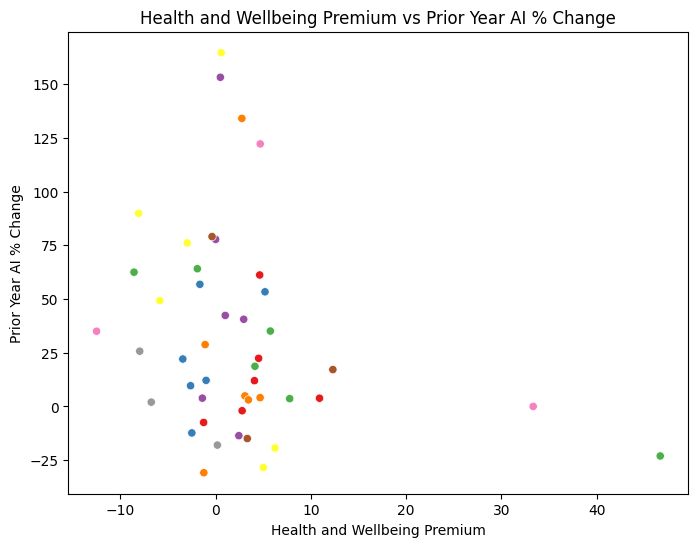

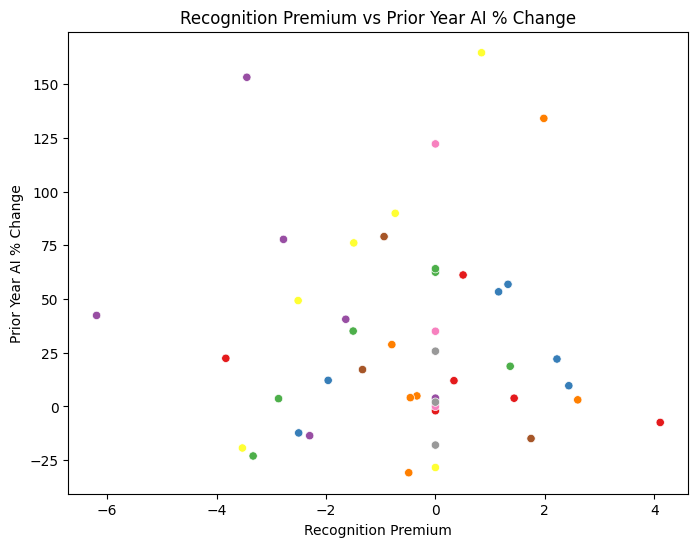

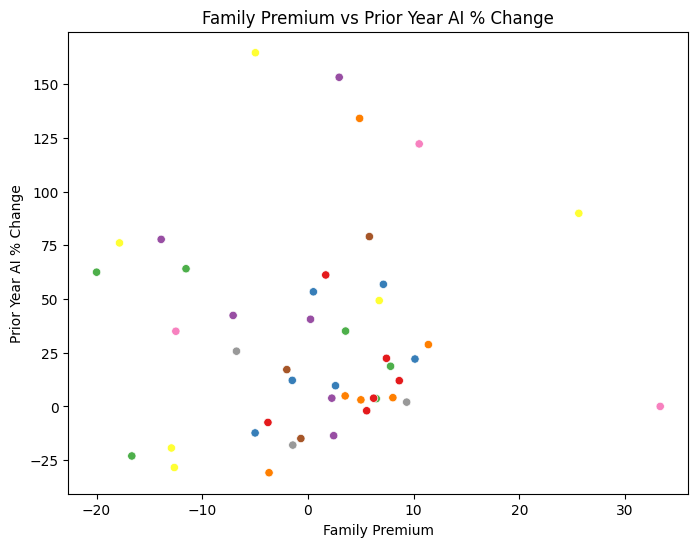

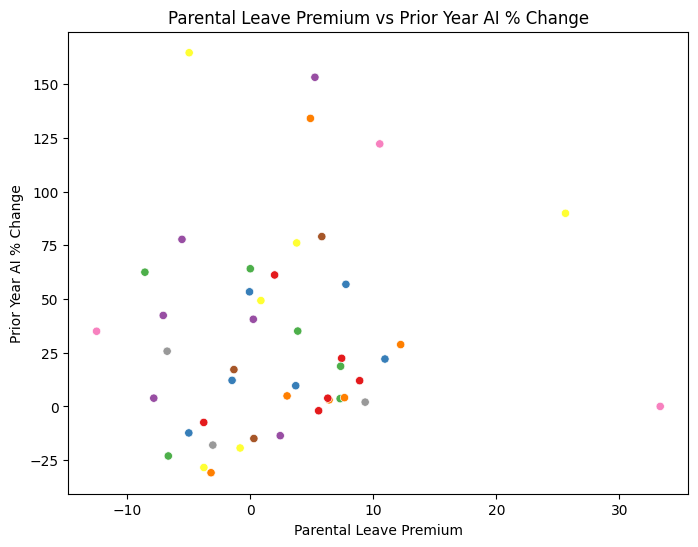

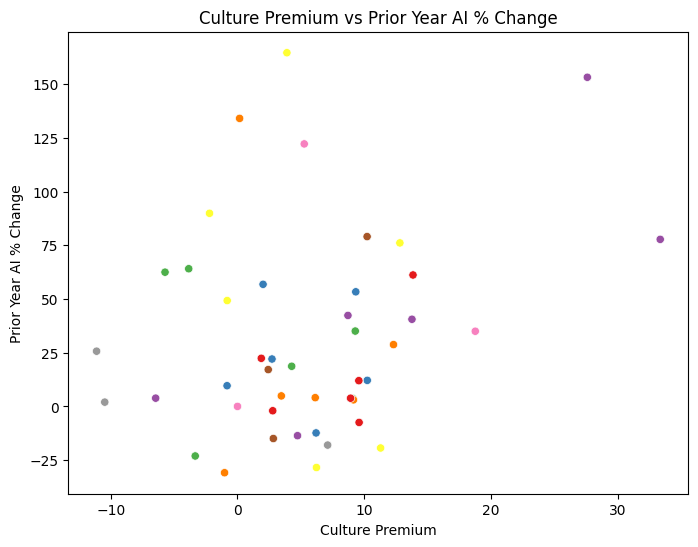

In [275]:
for i, benefit in enumerate(benefits3):
    plt.figure(figsize=(8, 6))
    
    # Create a scatterplot with color mapped to 'SOC_2021_2_NAME' (occupation)
    sns.scatterplot(
        data=occ_year_df, 
        x=f'{benefit}_premium', 
        y='PRIOR YEAR % CHANGE', 
        hue='SOC_2021_2_NAME',  # Color by occupation
        palette='Set1',         # Optional: Choose a color palette
        legend=False
    )
    
    # Set axis labels and title
    plt.xlabel(f'{benefits3_labels[i]} Premium')
    plt.ylabel('Prior Year AI % Change')
    plt.title(f'{benefits3_labels[i]} Premium vs Prior Year AI % Change')
    plt.savefig(f'../figures/scatter_premium_prior_year_change_{benefit}.png')
    
    # Show the plot
    plt.show()

# Vs. Salary Premium

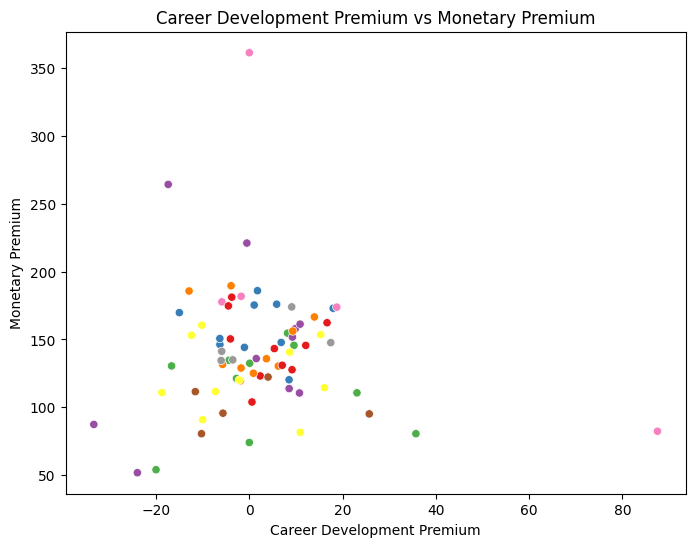

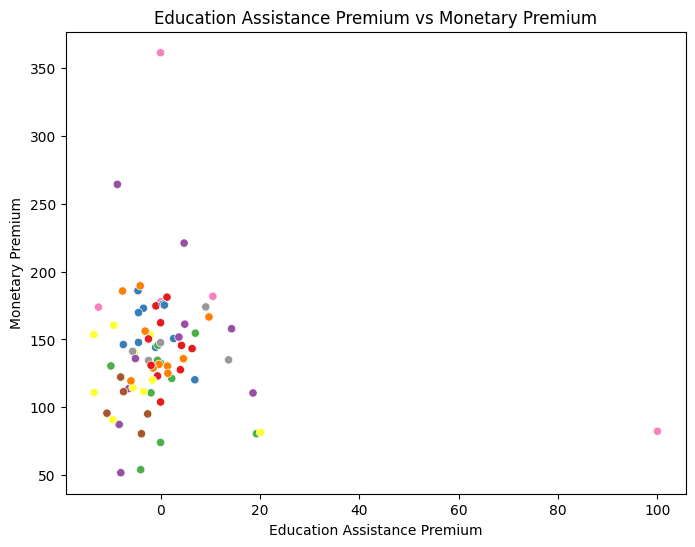

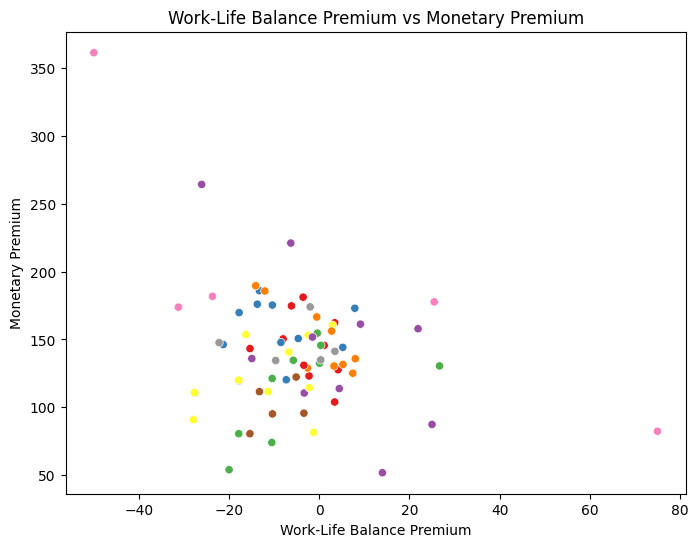

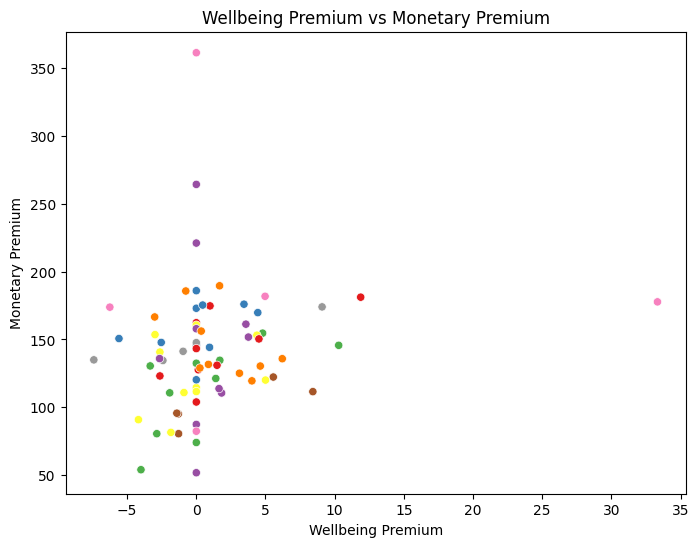

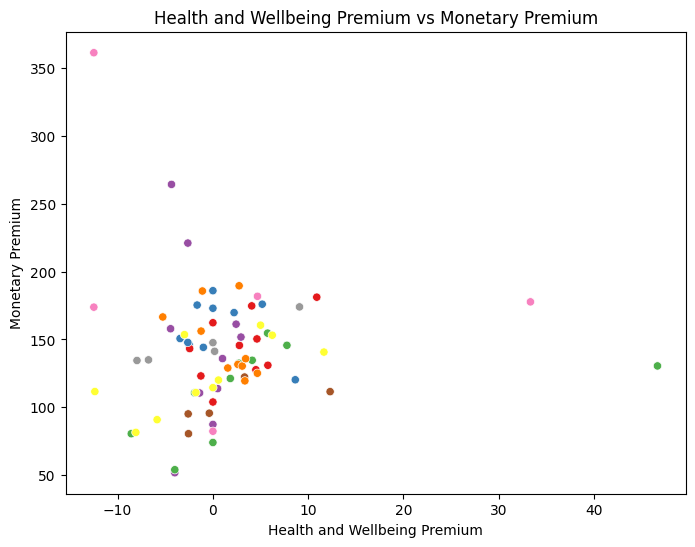

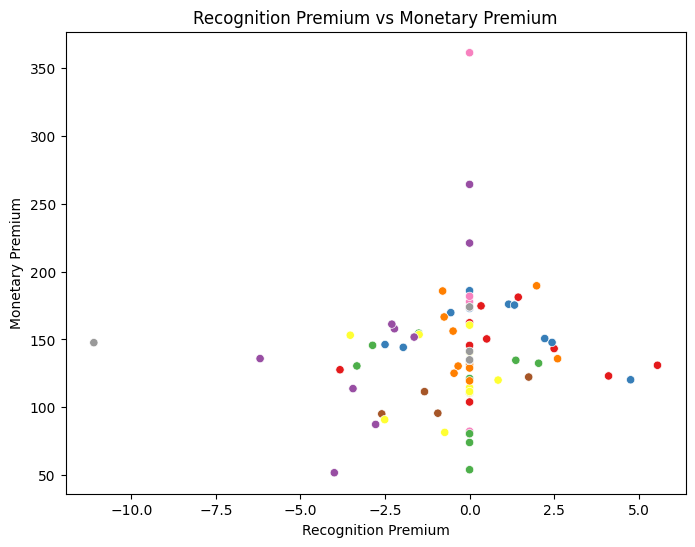

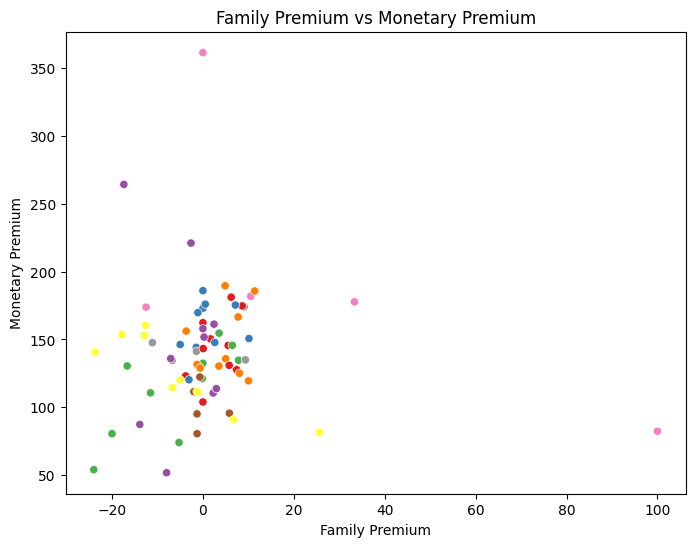

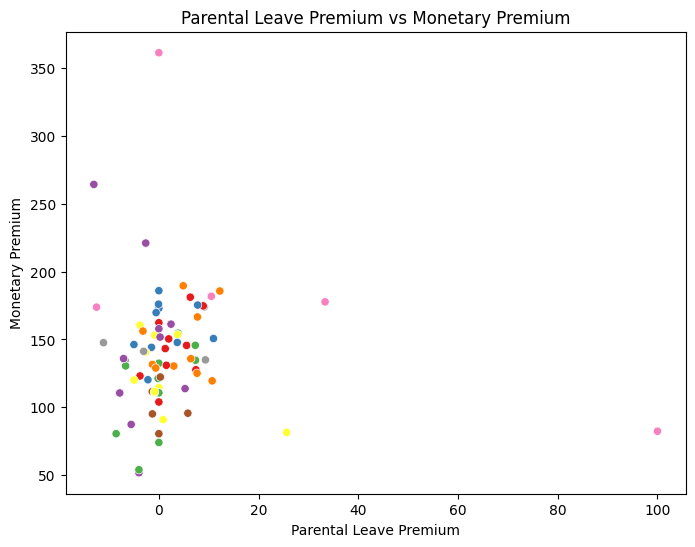

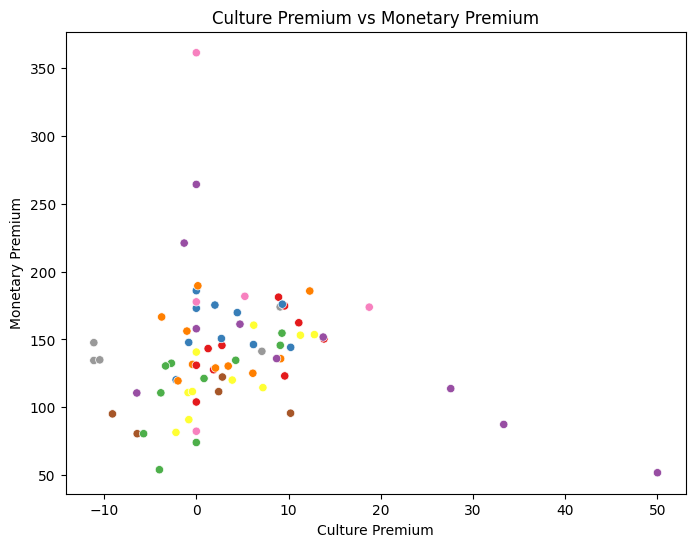

In [182]:
for i, benefit in enumerate(benefits3):
    plt.figure(figsize=(8, 6))
    
    # Create a scatterplot with color mapped to 'SOC_2021_2_NAME' (occupation)
    sns.scatterplot(
        data=occ_year_df, 
        x=f'{benefit}_premium', 
        y='SALARY_PREMIUM', 
        hue='SOC_2021_2_NAME',  # Color by occupation
        palette='Set1',         # Optional: Choose a color palette
        legend=False
    )
    
    # Set axis labels and title
    plt.xlabel(f'{benefits3_labels[i]} Premium')
    plt.ylabel('Monetary Premium')
    plt.title(f'{benefits3_labels[i]} Premium vs Monetary Premium')
    plt.savefig(f'../figures/scatter_premium_salary_{benefit}.png')
    
    # Show the plot
    plt.show()

## Vs. Log Salary Premium

In [202]:
occ_year_df.columns

Index(['SOC_2021_2_NAME', 'YEAR', 'CAREER_DEV_premium',
       'EDU_ASSISTANCE_premium', 'WLB_premium', 'WELLBEING_premium',
       'HEALTH_WELLBEING_premium', 'RECOGNITION_premium', 'FAMILY_premium',
       'PARENTAL_LEAVE_premium', 'CULTURE_premium', 'AI ROLE %',
       'AI ROLE % CHANGE', 'PRIOR YEAR % CHANGE', 'LOG_SALARY_ai', 'SALARY_ai',
       'LOG_SALARY_non_ai', 'SALARY_non_ai', 'SALARY_PREMIUM_LOG',
       'SALARY_PREMIUM', 'MEAN SALARY', 'MEAN LOG SALARY'],
      dtype='object')

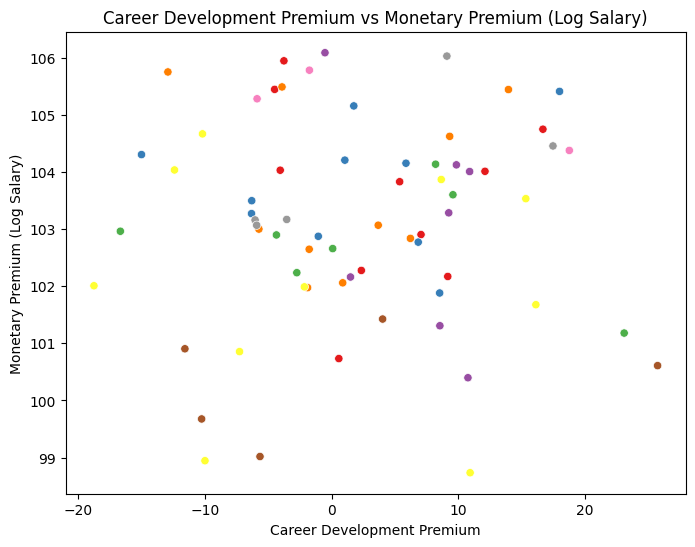

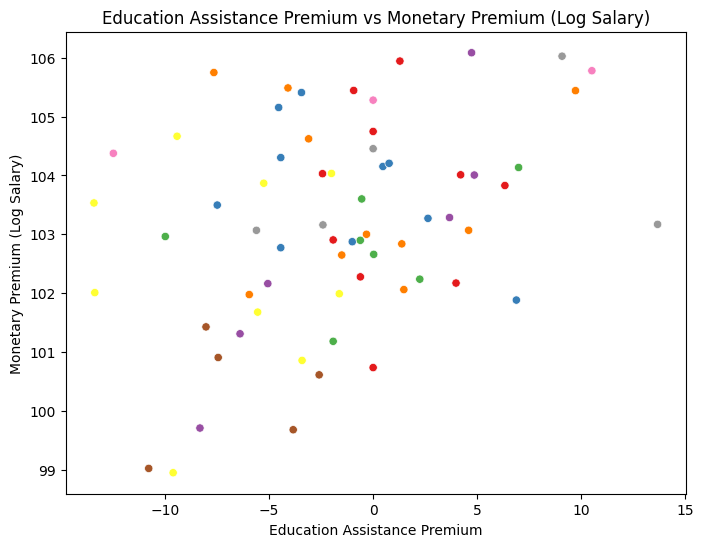

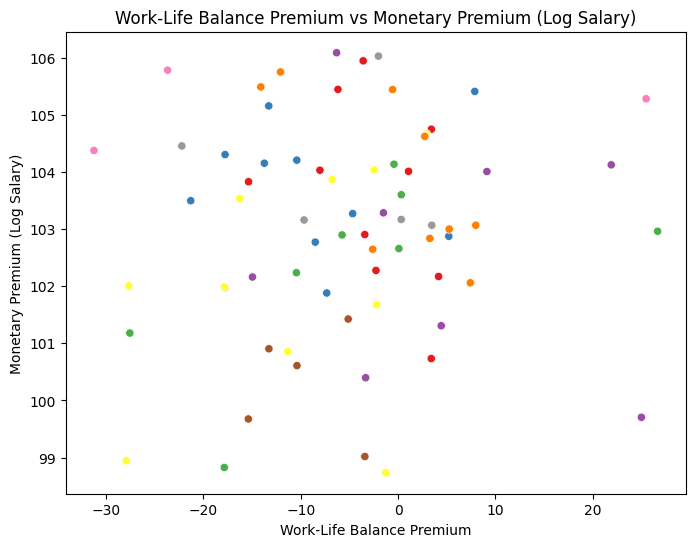

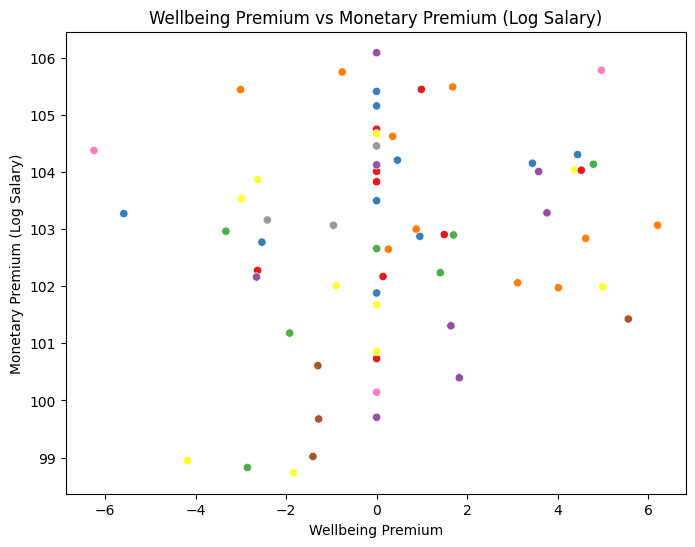

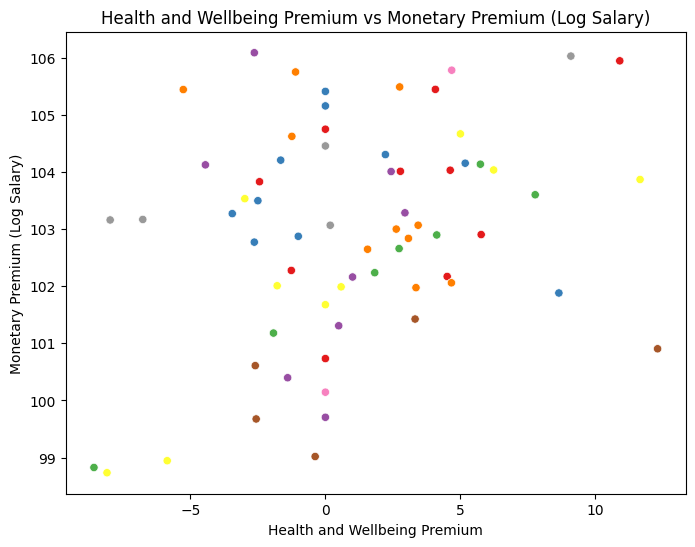

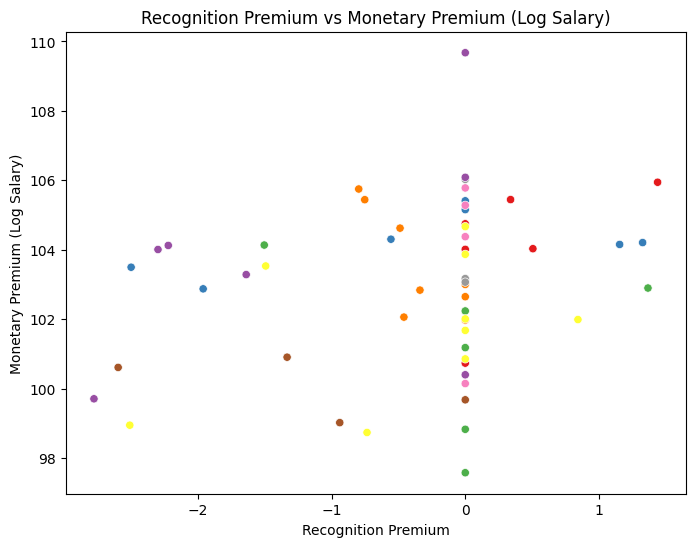

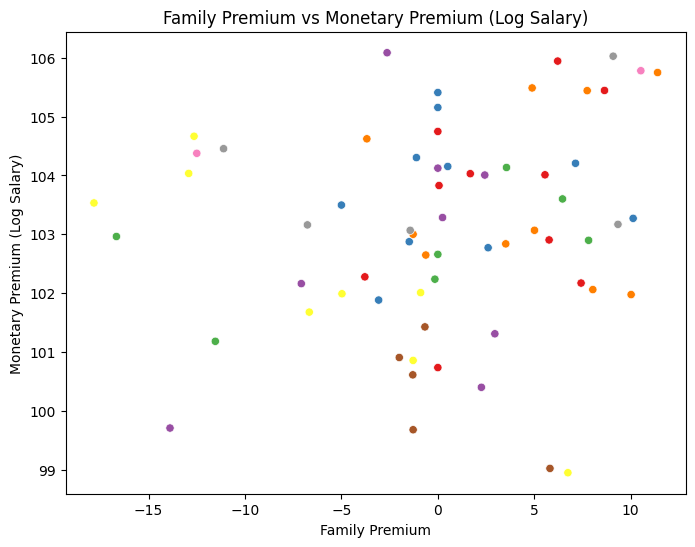

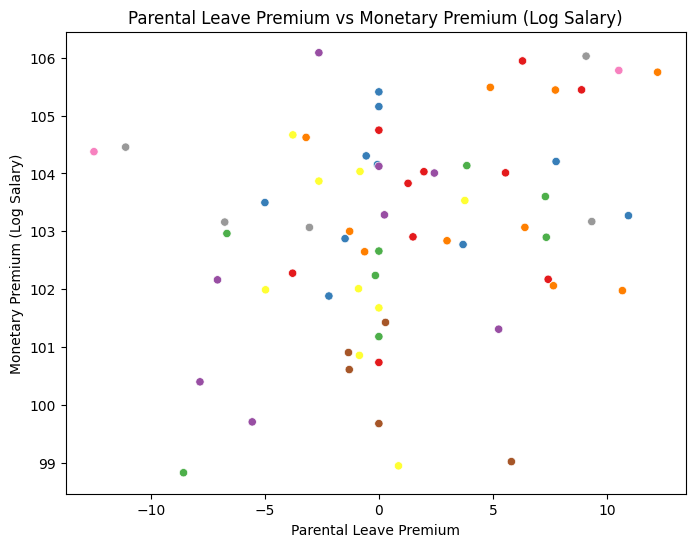

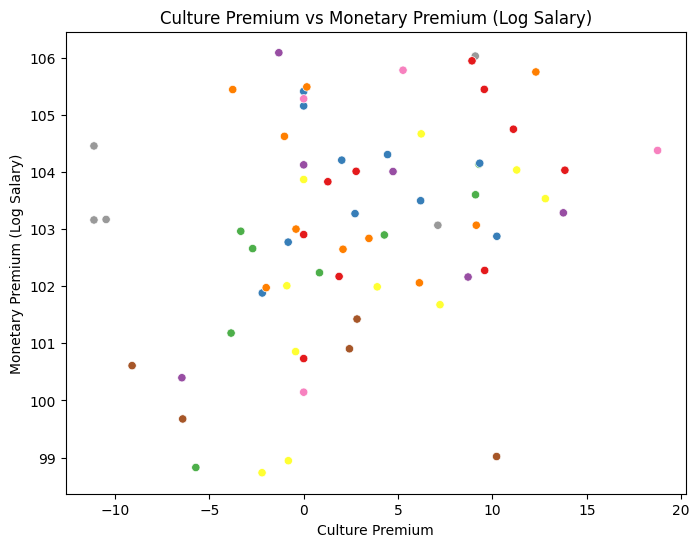

In [273]:
for i, benefit in enumerate(benefits3):
    plt.figure(figsize=(8, 6))
    filtered_df = remove_outliers(occ_year_df, f'{benefit}_premium')
    filtered_df = remove_outliers(filtered_df, 'SALARY_PREMIUM_LOG')
    
    # Create a scatterplot with color mapped to 'SOC_2021_2_NAME' (occupation)
    sns.scatterplot(
        data=filtered_df, 
        x=f'{benefit}_premium', 
        y='SALARY_PREMIUM_LOG', 
        hue='SOC_2021_2_NAME',  # Color by occupation
        palette='Set1',         # Optional: Choose a color palette
        legend=False
    )
    
    # Set axis labels and title
    plt.xlabel(f'{benefits3_labels[i]} Premium')
    plt.ylabel('Monetary Premium (Log Salary)')
    plt.title(f'{benefits3_labels[i]} Premium vs Monetary Premium (Log Salary)')
    plt.savefig(f'../figures/scatter_premium_log_salary_{benefit}.png')
    
    # Show the plot
    plt.show()

# % Benefits Vs. Salary

In [185]:
occ_year_df

,SOC_2021_2_NAME,YEAR,CAREER_DEV_premium,EDU_ASSISTANCE_premium,WLB_premium,WELLBEING_premium,HEALTH_WELLBEING_premium,RECOGNITION_premium,FAMILY_premium,PARENTAL_LEAVE_premium,CULTURE_premium,AI ROLE %,AI ROLE % CHANGE,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,SALARY_PREMIUM_LOG,SALARY_PREMIUM
0,Architecture and Engineering Occupations,2019,0.568,0.000,3.409,0.000,0.000,0.000,0.000,0.000,0.000,0.592593,NaN,NaN,11.387150,90796.187500,11.304232,87393.727273,100.733518,103.893255
1,Architecture and Engineering Occupations,2020,16.667,0.000,3.419,0.000,0.000,0.000,0.000,0.000,11.111,0.580645,-2.016129,NaN,11.597093,116638.722222,11.071426,71873.923077,104.747961,162.282393
2,Architecture and Engineering Occupations,2021,12.097,4.211,1.075,0.000,2.778,0.000,5.556,5.556,2.778,0.537313,-7.462687,-2.016129,11.561868,109740.583333,11.116007,75378.483871,104.010986,145.586085
3,Architecture and Engineering Occupations,2022,2.343,-0.613,-2.271,-2.632,-1.262,4.110,-3.785,-3.785,9.589,0.657658,22.397397,-7.462687,11.631612,119629.904110,11.372761,97191.000000,102.276066,123.087430
4,Architecture and Engineering Occupations,2023,9.161,3.989,4.163,0.142,4.510,-3.832,7.427,7.427,1.876,0.782383,18.965150,22.397397,11.673177,124427.569536,11.425182,97466.666667,102.170600,127.661665
5,"Arts, Design, Entertainment, Sports, and Media...",2019,1.748,-4.545,-13.287,0.000,0.000,0.000,0.000,0.000,0.000,0.371429,NaN,NaN,11.261190,91136.461538,10.709071,49025.636364,105.155622,185.895520
6,"Arts, Design, Entertainment, Sports, and Media...",2020,17.980,-3.448,7.882,0.000,0.000,0.000,0.000,0.000,0.000,0.325581,-12.343470,NaN,11.113737,73104.142857,10.543366,42266.965517,105.409760,172.958106
7,"Arts, Design, Entertainment, Sports, and Media...",2021,-6.304,-7.500,-21.304,0.000,-2.500,-2.500,-5.000,-5.000,6.196,0.365079,12.131519,-12.343470,11.057736,69753.521739,10.684153,47705.175000,103.496608,146.217935
8,"Arts, Design, Entertainment, Sports, and Media...",2022,-1.052,-1.004,5.213,0.956,-1.004,-1.961,-1.483,-1.483,10.234,0.445652,22.069943,12.131519,11.063884,76376.609756,10.754831,52980.098039,102.873623,144.160945
9,"Arts, Design, Entertainment, Sports, and Media...",2023,-6.319,2.639,-4.664,-5.590,-3.449,2.222,10.127,10.949,2.720,0.678392,52.224537,22.069943,11.156510,83305.251852,10.803178,55299.859375,103.270630,150.642791


In [274]:
len(occ_year_df)

75

In [196]:
mean_salary = even_sample_select.groupby([occupation, 'YEAR'])[['SALARY', 'LOG_SALARY']].mean().reset_index()

In [197]:
occ_year_df = occ_year_df.merge(mean_salary, on=[occupation, 'YEAR'])

In [190]:
pd.set_option('display.max_rows', 100)

In [192]:
occ_year_df.rename(columns={'SALARY':'MEAN SALARY'}, inplace=True)

In [199]:
occ_year_df.drop(columns='SALARY', inplace=True)

In [200]:
occ_year_df.rename(columns={'LOG_SALARY':'MEAN LOG SALARY'}, inplace=True)

In [220]:
occupation_benefits_all.columns

Index(['SOC_2021_2_NAME', 'YEAR', 'CAREER_DEV', 'EDU_ASSISTANCE', 'WLB',
       'WELLBEING', 'HEALTH_WELLBEING', 'RECOGNITION', 'FAMILY',
       'PARENTAL_LEAVE', 'CULTURE', 'MEAN_LOG_SALARY'],
      dtype='object')

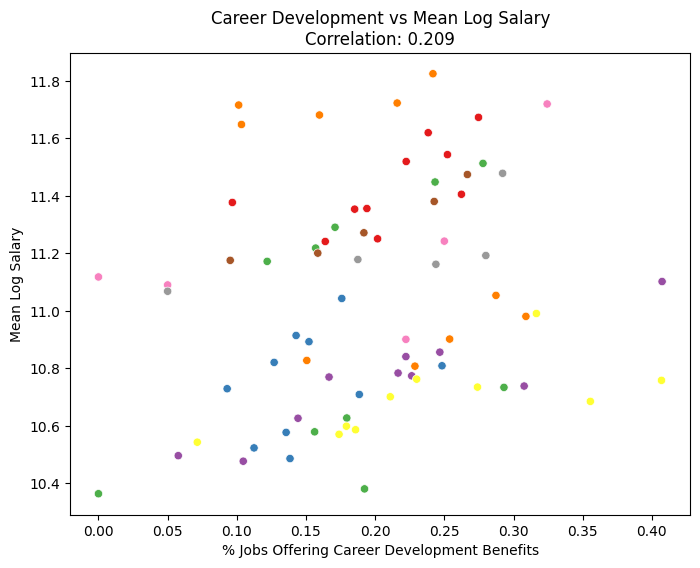

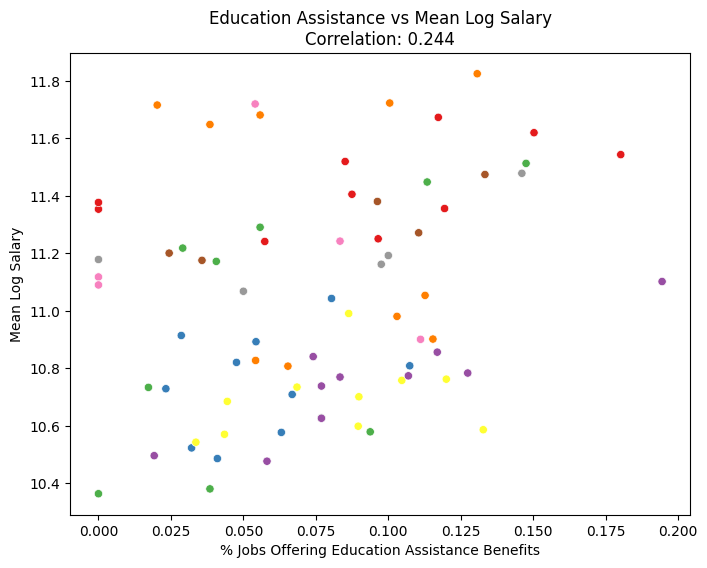

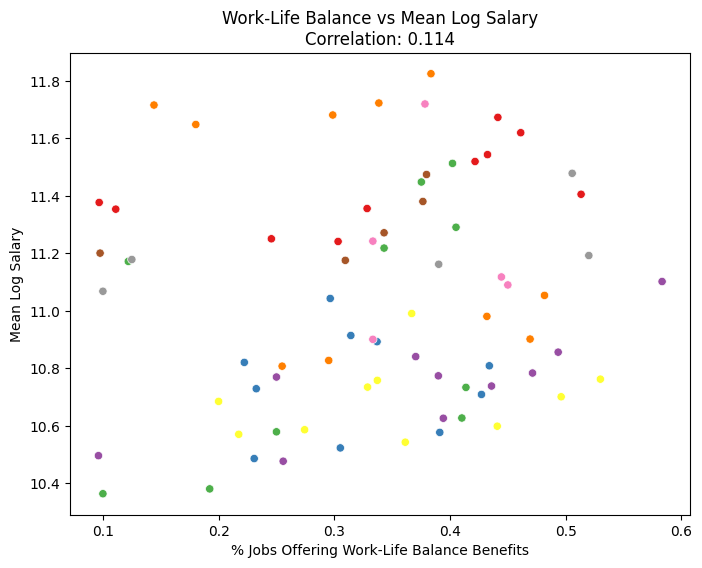

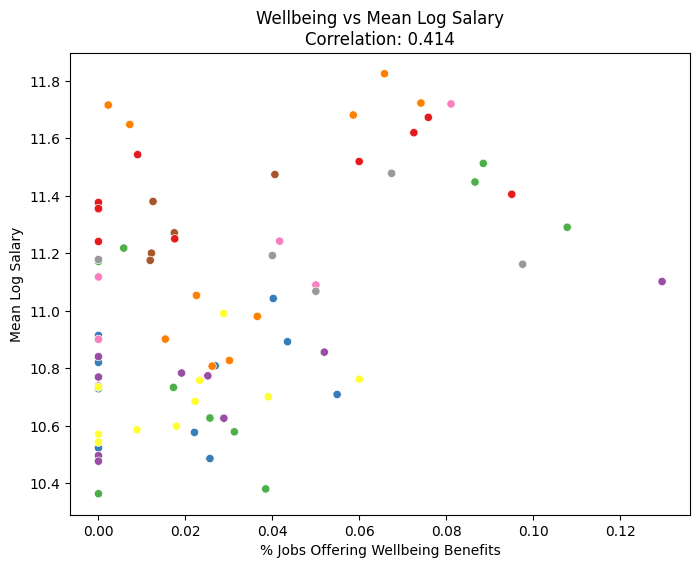

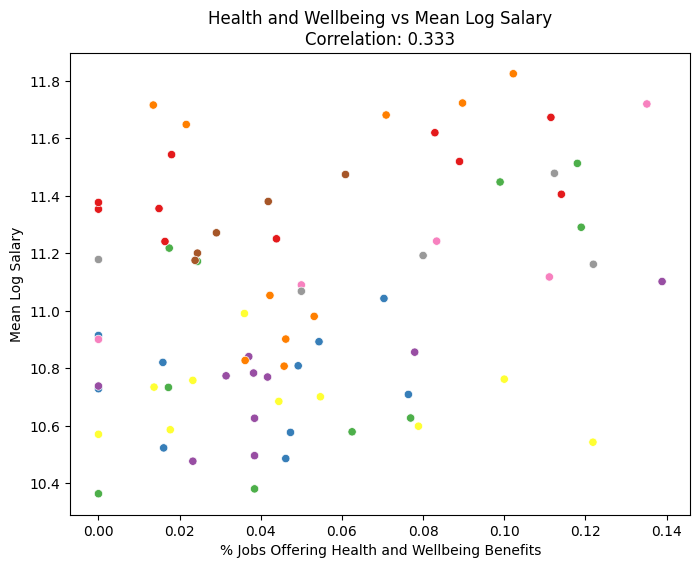

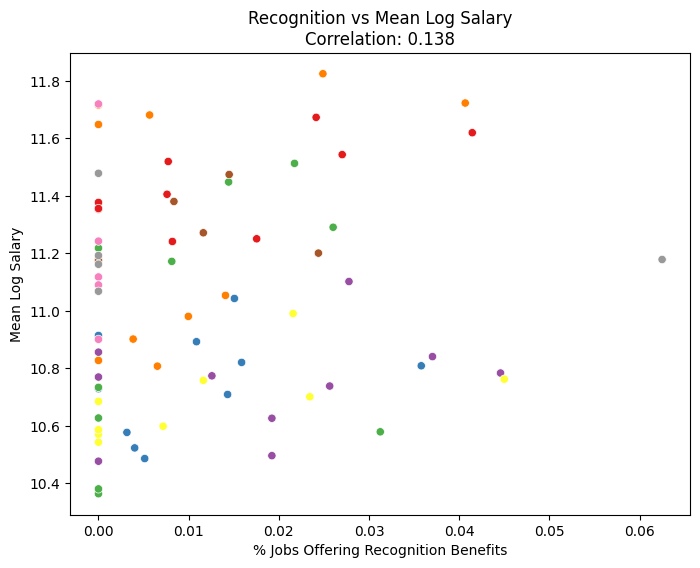

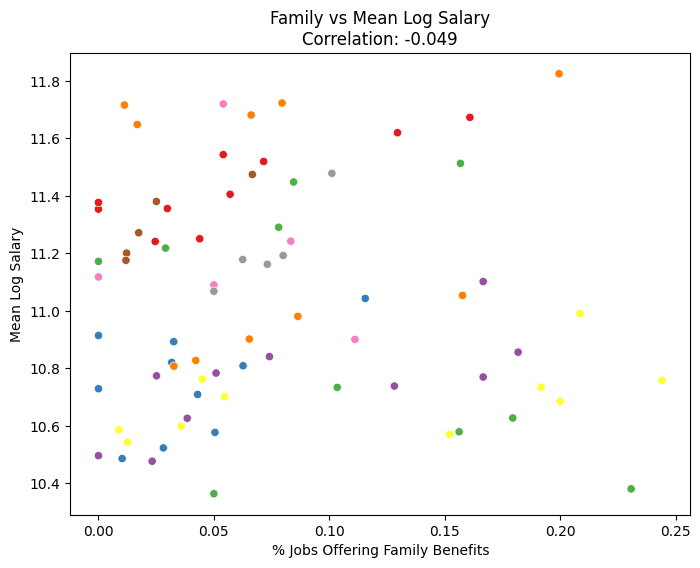

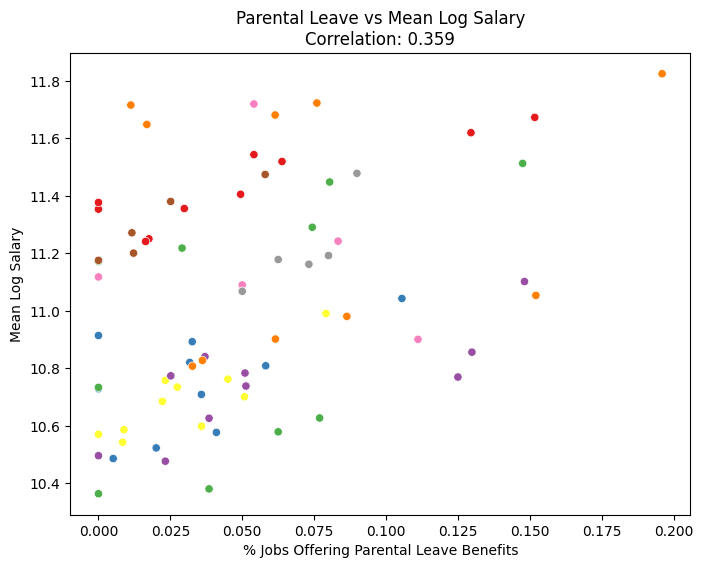

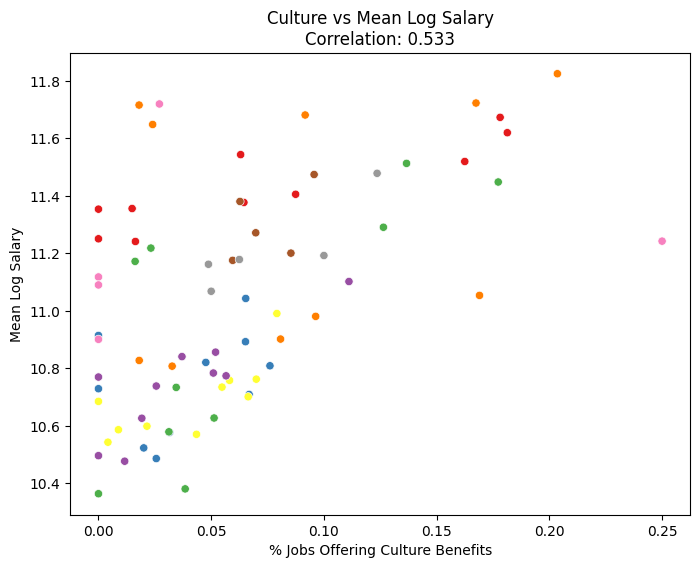

In [226]:
for i, benefit in enumerate(benefits3):
    plt.figure(figsize=(8, 6))
    # filtered_df = remove_outliers(occupation_benefits_all, f'{benefit}_premium')
    correlation = occupation_benefits_all[[f'{benefit}', 'MEAN_LOG_SALARY']].corr().iloc[0, 1]

    # Create a scatterplot with color mapped to 'SOC_2021_2_NAME' (occupation)
    sns.scatterplot(
        data=occupation_benefits_all, 
        x=f'{benefit}', 
        y='MEAN_LOG_SALARY', 
        hue='SOC_2021_2_NAME',  # Color by occupation
        palette='Set1',         # Optional: Choose a color palette
        legend=False
    )
    
    # Set axis labels and title
    plt.xlabel(f'% Jobs Offering {benefits3_labels[i]} Benefits')
    plt.ylabel('Mean Log Salary')
    plt.title(f'{benefits3_labels[i]} vs Mean Log Salary\nCorrelation: {correlation:.3f}')
    plt.savefig(f'../figures/scatter_log_salary_{benefit}_all.png')
    
    # Show the plot
    plt.show()

# Models

In [234]:
import sys
import os

# Get the absolute path to the folder containing my_module.py
module_path = os.path.abspath(os.path.join('..'))

# Add that directory to sys.path
sys.path.append(module_path)

In [235]:
from logit_model import *

In [236]:
occ_year_df.columns

Index(['SOC_2021_2_NAME', 'YEAR', 'CAREER_DEV_premium',
       'EDU_ASSISTANCE_premium', 'WLB_premium', 'WELLBEING_premium',
       'HEALTH_WELLBEING_premium', 'RECOGNITION_premium', 'FAMILY_premium',
       'PARENTAL_LEAVE_premium', 'CULTURE_premium', 'AI ROLE %',
       'AI ROLE % CHANGE', 'PRIOR YEAR % CHANGE', 'LOG_SALARY_ai', 'SALARY_ai',
       'LOG_SALARY_non_ai', 'SALARY_non_ai', 'SALARY_PREMIUM_LOG',
       'SALARY_PREMIUM', 'MEAN SALARY', 'MEAN LOG SALARY'],
      dtype='object')

In [238]:
# run linear regression model 
occ_models_demand = []
for benefit in benefits3:
    X = occ_year_df['AI ROLE %'] 
    y = occ_year_df[benefit + '_premium']
    # Fit the linear regression model
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    occ_models_demand.append(model)
    print(model.summary())




                            OLS Regression Results                            
Dep. Variable:     CAREER_DEV_premium   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                 8.757e-06
Date:                Fri, 11 Oct 2024   Prob (F-statistic):              0.998
Time:                        13:41:40   Log-Likelihood:                -311.23
No. Observations:                  75   AIC:                             626.5
Df Residuals:                      73   BIC:                             631.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2942      2.905      0.790      0.4

In [240]:
occ_year_df['AI ROLE % CHANGE'].value_counts(dropna=False)

AI ROLE % CHANGE
 NaN           15
 122.222222     1
 25.714286      1
 1.995565       1
-18.000000      1
               ..
 17.142857      1
 79.069767      1
-14.948650      1
-12.073579      1
 43.058824      1
Name: count, Length: 61, dtype: int64

In [241]:
# run linear regression model 
occ_models_demand_change = []
for benefit in benefits3:
    # drop nas from AI ROLE % CHANGE
    model_df = occ_year_df.dropna(subset=['AI ROLE % CHANGE'])
    X = model_df['AI ROLE % CHANGE'] 
    y = model_df[benefit + '_premium']
    # Fit the linear regression model
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    occ_models_demand_change.append(model)
    print(model.summary())




                            OLS Regression Results                            
Dep. Variable:     CAREER_DEV_premium   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.016
Method:                 Least Squares   F-statistic:                   0.08028
Date:                Fri, 11 Oct 2024   Prob (F-statistic):              0.778
Time:                        13:44:57   Log-Likelihood:                -231.43
No. Observations:                  60   AIC:                             466.9
Df Residuals:                      58   BIC:                             471.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.1288      1.849  

In [248]:
occ_models_demand_change_prior = []
for benefit in benefits3:
    # drop nas from PRIOR YEAR % CHANGE
    model_df = occ_year_df.dropna(subset=['PRIOR YEAR % CHANGE'])
    X = model_df['PRIOR YEAR % CHANGE'] 
    y = model_df[benefit + '_premium']
    # Fit the linear regression model
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    occ_models_demand_change_prior.append(model)
    print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     CAREER_DEV_premium   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                    0.4124
Date:                Fri, 11 Oct 2024   Prob (F-statistic):              0.524
Time:                        14:03:36   Log-Likelihood:                -173.17
No. Observations:                  45   AIC:                             350.3
Df Residuals:                      43   BIC:                             353.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.3957    

In [264]:
occ_models_monetary_premium = []
for benefit in benefits3:
    # drop nas from PRIOR YEAR % CHANGE
    model_df = occ_year_df.dropna(subset=['SALARY_PREMIUM_LOG'])
    X = model_df['SALARY_PREMIUM_LOG'] 
    y = model_df[benefit + '_premium']
    # Fit the linear regression model
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    occ_models_monetary_premium.append(model)
    print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     CAREER_DEV_premium   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                  0.005151
Date:                Fri, 11 Oct 2024   Prob (F-statistic):              0.943
Time:                        14:10:37   Log-Likelihood:                -311.23
No. Observations:                  75   AIC:                             626.5
Df Residuals:                      73   BIC:                             631.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -2.6437     68

In [242]:
def create_results_df(model_list, benefit_list, variable, description):
    coefficients = []
    errors = []
    pvalues = []
    for model in model_list:
        try:
            coef = model.params[variable]
            err = model.bse[variable]
            pvalue = model.pvalues[variable].round(3)
        except:
            coef = None
            err = None
            pvalue = None

        coefficients.append(coef)
        errors.append(err)
        pvalues.append(pvalue)

    # Creating DataFrame
    results = {
        'Label': benefit_list,
        'Coefficient': coefficients,
        'Error': errors,
        'P-Value': pvalues
    }

    results_df = pd.DataFrame(results)
    results_df['Model Iteration'] = description
    return results_df

In [270]:
def plot_model_results(results_df, benefits_list):
    # Define colors for each model
    colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']
    # Calculate the 95% confidence intervals
    results_df['Lower_CI'] = results_df['Coefficient'] - 1.96 * results_df['Error']
    results_df['Upper_CI'] = results_df['Coefficient'] + 1.96 * results_df['Error']

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))

    # benefits = benefits
    model_iterations = results_df['Model Iteration'].unique()
    markers = ['o', 's', '^', 'D']  # Different markers for model iterations
    positions = []
    current_pos = 0

    # Store legend handles and labels to avoid duplicates
    handles, labels = [], []

    for benefit in benefits_list:
        benefit_data = results_df[results_df['Label'] == benefit]
        benefit_positions = []
        for i, model in enumerate(model_iterations):
            model_data = benefit_data[benefit_data['Model Iteration'] == model]
            if not model_data.empty:
                pos = current_pos + i * 0.2  # Adjust spacing between model_iterations within the same benefit
                handle = ax.errorbar(
                    pos, model_data['Coefficient'].values, 
                    yerr=[model_data['Coefficient'].values - model_data['Lower_CI'].values, 
                        model_data['Upper_CI'].values - model_data['Coefficient'].values], 
                    fmt=markers[i], color=colors[i], label=model if benefit == benefits_list[0] else ""
                )
                benefit_positions.append(pos)
                if benefit == benefits_list[0]:  # Add handles and labels only for the first benefit to avoid duplicates
                    handles.append(handle)
                    labels.append(model)
        positions.extend(benefit_positions)
        current_pos += len(model_iterations) + 1  # Add more space between different benefits

    # Customize plot
    benefit_ticks = [(positions[i * len(model_iterations)] + positions[(i + 1) * len(model_iterations) - 1]) / 2 for i in range(len(benefits_list))]
    ax.set_xticks(benefit_ticks, labels = benefits3_labels)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xticklabels(benefits3_labels, rotation=45, fontsize = 14, ha='right')
    # ax.set_title('AI Skill Coefficients by benefit and Occupation')
    ax.set_xlabel(None)
    ax.set_ylabel('Log-Odds Coefficient (with 95% CI)', fontsize=16)
    ax.axhline(0, color='grey', linewidth=0.8)
    ax.legend(handles, labels, title='Model', bbox_to_anchor=(0, 1), loc = 'upper left', fontsize = 12, title_fontsize = 12)
    # ax.axhline(average_coefficient, color='black', linestyle='--', linewidth=1, label='Average Coefficient')
    plt.title('Occupation-Year OLS Models \n(Dependent Variable: Benefit Premium)', fontsize=18)
    plt.tight_layout()
    plt.savefig('../figures/occ_model_coefficients_plot.png')
    plt.show()


In [259]:
results_demand = create_results_df(occ_models_demand, benefits3, 'AI ROLE %', 'AI Demand')

In [246]:
results_demand

,Label,Coefficient,Error,P-Value,Model Iteration
0,CAREER_DEV,0.020654,6.979554,0.998,Demand
1,EDU_ASSISTANCE,0.532793,6.162926,0.931,Demand
2,WLB,9.100585,7.261453,0.214,Demand
3,WELLBEING,2.032299,2.314598,0.383,Demand
4,HEALTH_WELLBEING,2.753104,3.727127,0.462,Demand
5,RECOGNITION,0.814809,1.035304,0.434,Demand
6,FAMILY,5.180638,6.764932,0.446,Demand
7,PARENTAL_LEAVE,0.270180,6.094973,0.965,Demand
8,CULTURE,3.072287,4.214520,0.468,Demand


In [260]:
results_demand_change = create_results_df(occ_models_demand_change, benefits3, 'AI ROLE % CHANGE', 'AI Demand Change')

In [261]:
results_demand_change_prior = create_results_df(occ_models_demand_change_prior, benefits3, 'PRIOR YEAR % CHANGE', 'AI Demand Change Prior Year')

In [265]:
results_monetary_premium = create_results_df(occ_models_monetary_premium, benefits3, 'SALARY_PREMIUM_LOG', 'Monetary Premium (Log Salary)')

In [266]:
results_df = pd.concat([results_demand, results_demand_change, results_demand_change_prior, results_monetary_premium])

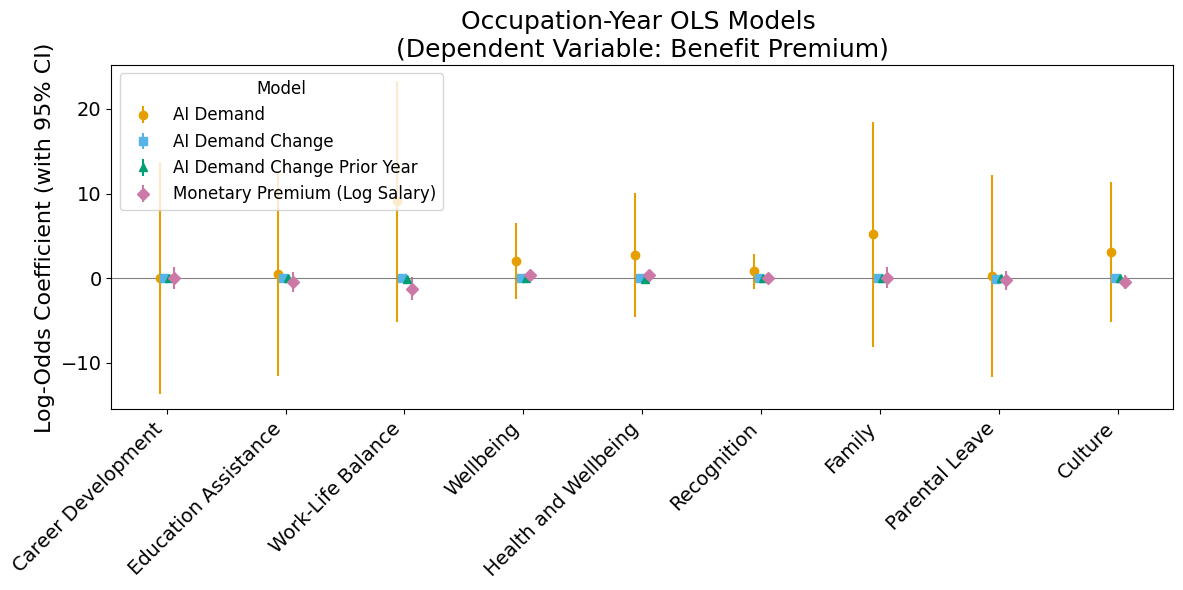

In [271]:
plot_model_results(results_df, benefits3)

# Benefits by Occupation & Role Type

In [321]:
def get_benefit_by_occupation(even_sample, benefit):
    occ_ai_benefit_group = even_sample.groupby([occupation, 'AI ROLE',benefit]).size().reset_index(name='benefit_count')
    occ_ai_group = even_sample.groupby([occupation, 'AI ROLE']).size().reset_index(name='count')
    occ_ai_benefit_group = occ_ai_benefit_group.merge(occ_ai_group, on = ['SOC_2021_2_NAME','AI ROLE'], how = 'left')
    occ_ai_benefit_group[f'Percent with {benefit}'] = occ_ai_benefit_group['benefit_count']/occ_ai_benefit_group['count']
    occ_ai_benefit_percent = occ_ai_benefit_group[occ_ai_benefit_group[benefit] == 1.0].copy()
    # rename columns without setting copy of a slice
    
    
    occ_ai_benefit_percent.rename(columns = {'SOC_2021_2_NAME': 'Occupation'}, inplace=True)
    occ_ai_benefit_percent['AI ROLE'] = occ_ai_benefit_percent['AI ROLE'].map({True: 'Yes', False: 'No'})
    occ_ai_benefit_percent['Occupation'] = occ_ai_benefit_percent['Occupation'].str.replace(' Occupations', '')

    return occ_ai_benefit_percent
    

In [322]:
benefit_percent_dfs = []
for benefit in benefits3:
    occ_ai_benefit_percent = get_benefit_by_occupation(even_sample_select, benefit)
    benefit_percent_dfs.append(occ_ai_benefit_percent)

In [323]:
occ_ai_benefit_percent

,Occupation,AI ROLE,CULTURE,benefit_count,count,Percent with CULTURE
1,Architecture and Engineering,No,True,7,135,0.051852
3,Architecture and Engineering,Yes,True,38,294,0.129252
5,"Arts, Design, Entertainment, Sports, and Media",No,True,5,206,0.024272
7,"Arts, Design, Entertainment, Sports, and Media",Yes,True,17,226,0.075221
9,Business and Financial Operations,No,True,50,629,0.079491
...,...,...,...,...,...,...
50,Production,Yes,True,12,115,0.104348
52,Sales and Related,No,True,77,948,0.081224
54,Sales and Related,Yes,True,41,287,0.142857
56,Transportation and Material Moving,No,True,36,1038,0.034682


In [324]:
def plot_benefit_occ_percents(df, benefit):
    sorted_data = df[df['AI ROLE'] == 'No']
    sorted_data = sorted_data.sort_values(by=f'Percent with {benefit}', ascending=True)

    # Create a figure and axis object
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot the data as a clustered bar chart
    sns.barplot(x=f'Percent with {benefit}', y='Occupation', hue='AI ROLE', data=df, order=sorted_data['Occupation'], ax=ax)

    # Set the labels and title
    ax.set_xlabel(f'Percent with {benefit}', fontsize=14)
    ax.set_ylabel('Occupation', fontsize=14)
    ax.set_title(None)

    # Add value labels without decimals
    # for p in ax.patches:
    #     width = p.get_width()
    #     ax.annotate(f'{width:.1f}%', (p.get_x() + p.get_width(), p.get_y() + p.get_height() / 2.),
    #                 ha='center', va='center', fontsize=12, color='black', xytext=(5, 0),
    #                 textcoords='offset points')

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Adjust the legend position and title
    plt.legend(title='AI ROLE', bbox_to_anchor=(1.02, 1), loc='upper left')

    # Adjust spacing between subplots
    plt.subplots_adjust(bottom=0.2, left=0.1, right=0.9, top=0.9)
    plt.tight_layout()
    plt.savefig(f'../figures/percent_by_occupation_{benefit}.png')
    # Show the plot
    plt.show()

In [326]:
# set font size
plt.rcParams.update({'font.size': 14})

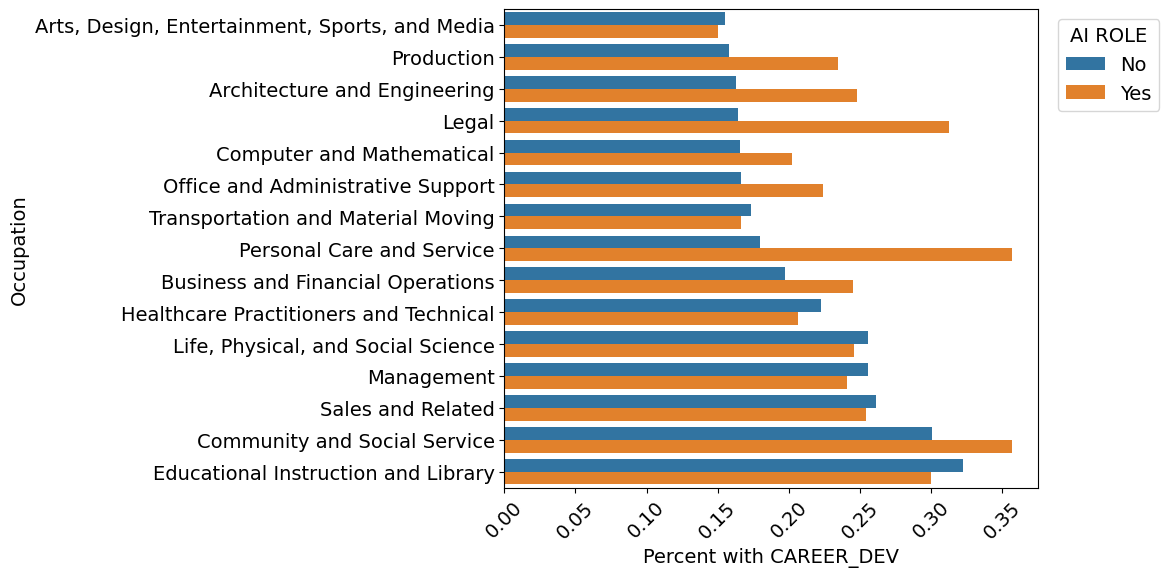

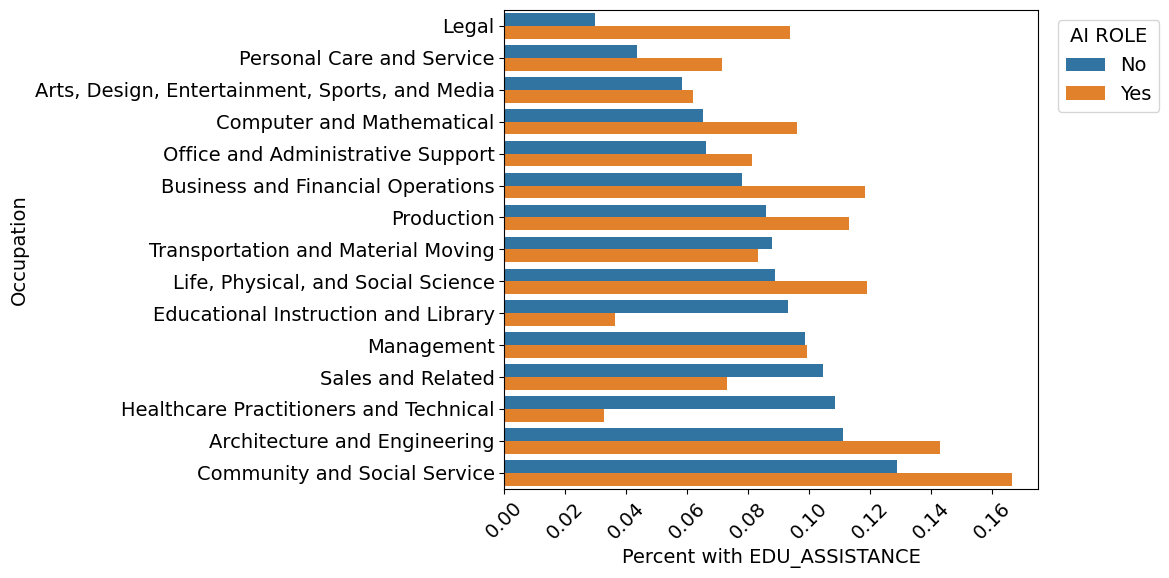

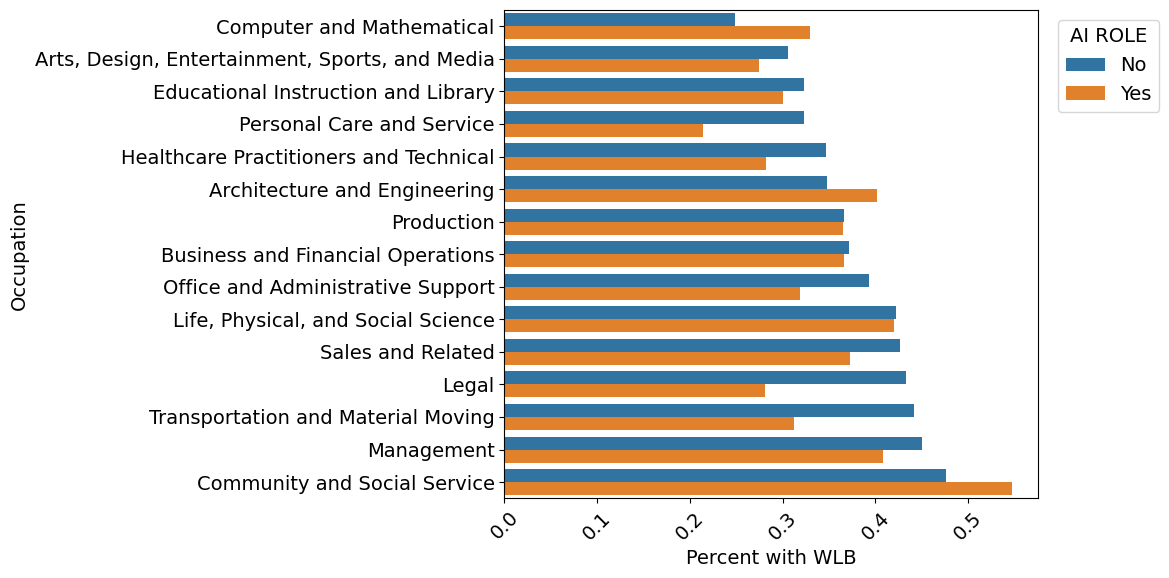

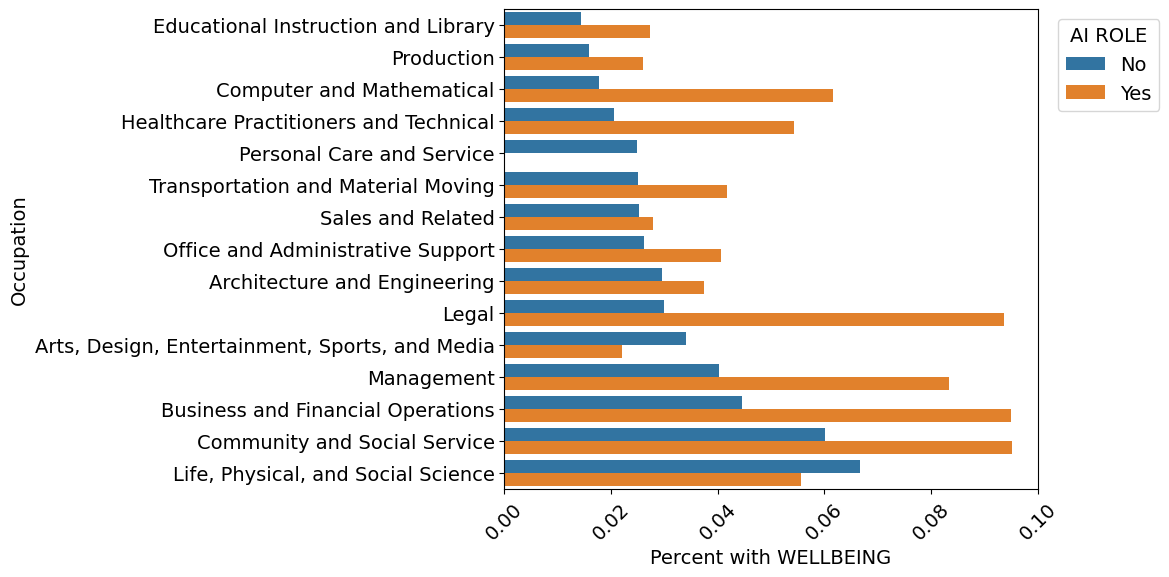

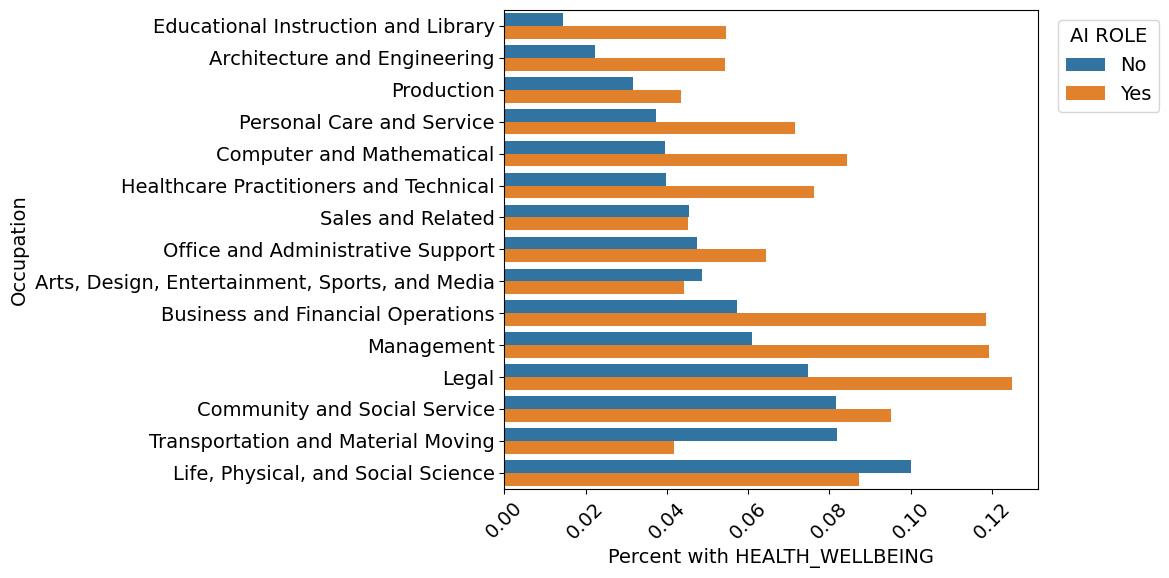

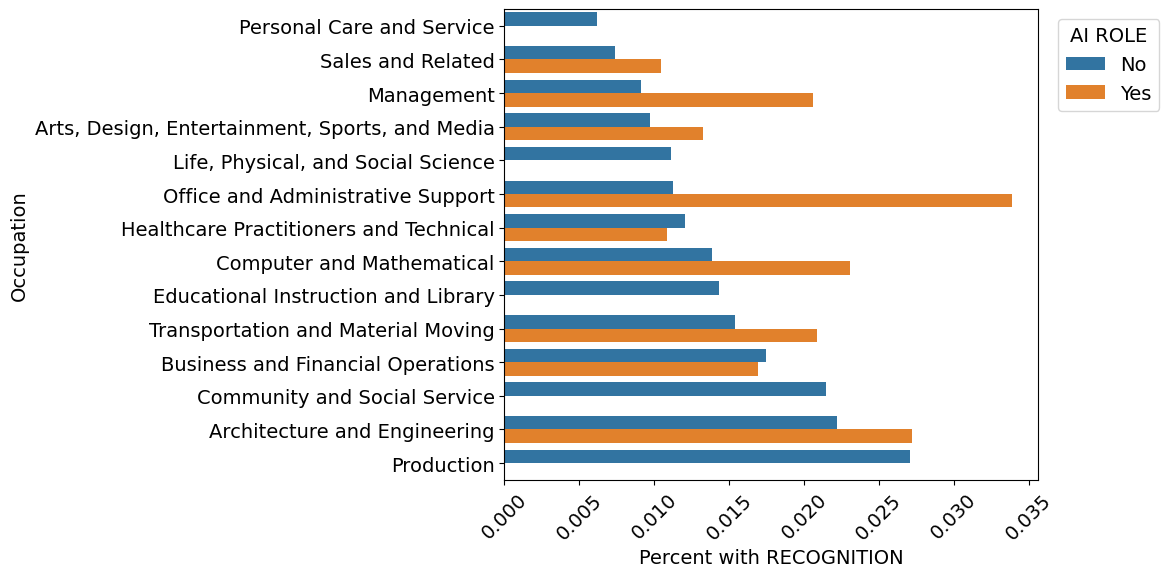

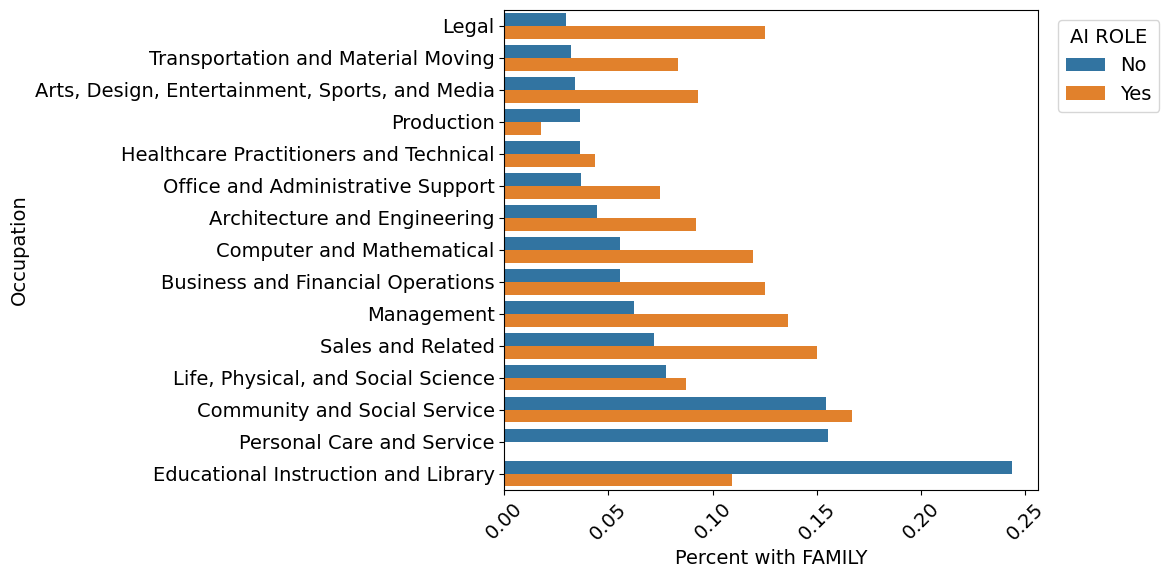

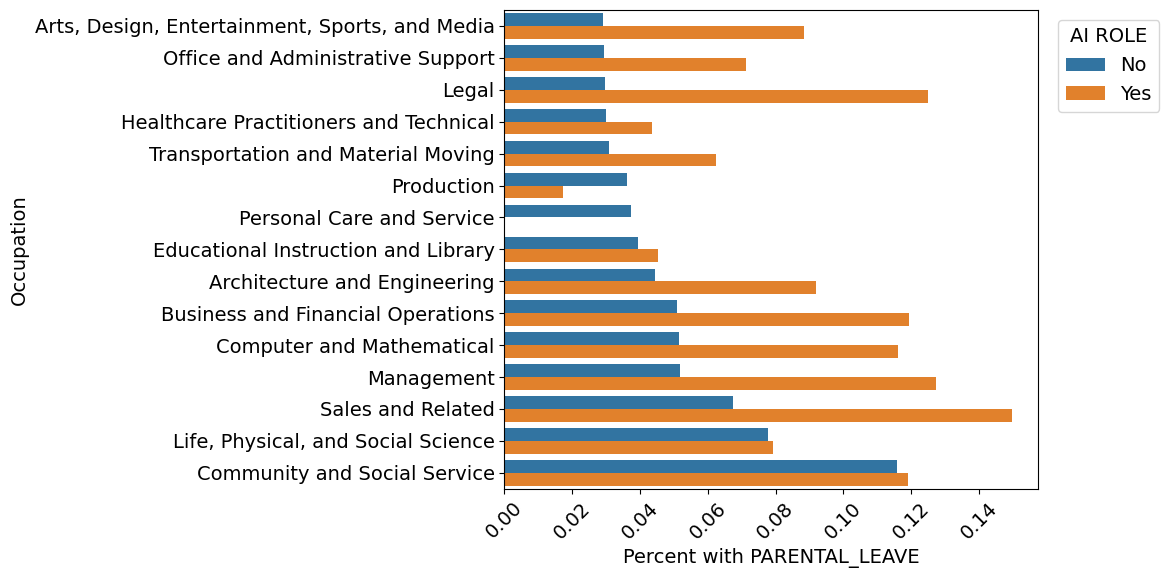

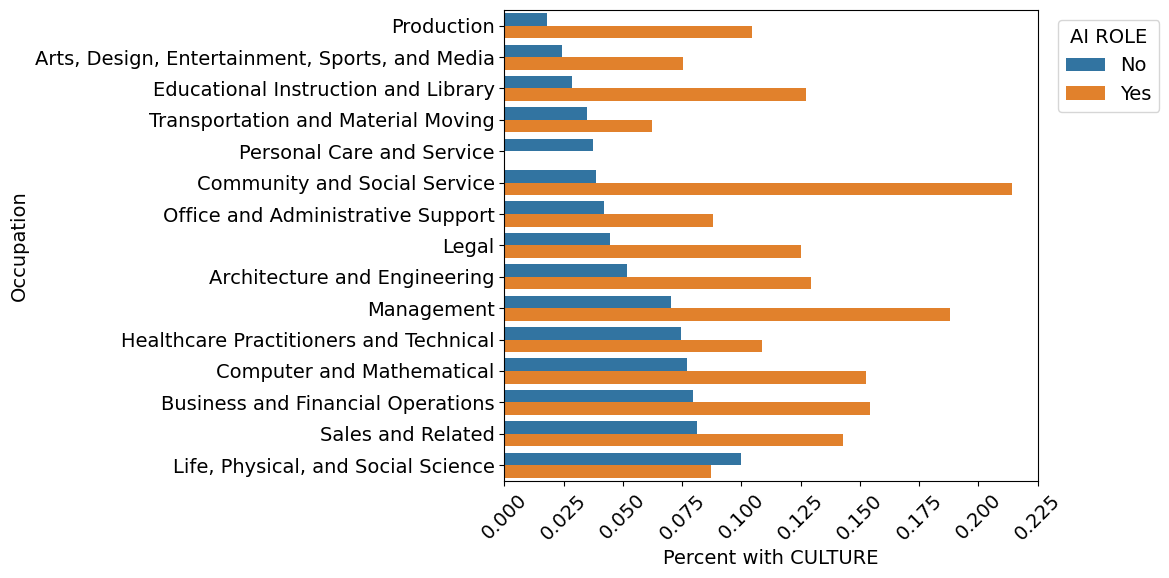

In [327]:
for df, benefit in zip(benefit_percent_dfs, benefits3):
    plot_benefit_occ_percents(df, benefit)

# Beta Coeffs

In [329]:
results = pd.read_csv('../../exports/models_occ_year_results.csv')